In [3]:
import mudata
scplus_mdata = mudata.read("../process/20241219_scenicplus_outs/scplusmdata.h5mu")

/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/zhanglab/mambaforge

In [23]:
sc.settings.figdir = "../result/regulation/20241221_scenicplus/"

In [6]:
import scanpy as sc
import anndata
eRegulon_gene_AUC = anndata.concat(
    [scplus_mdata["direct_gene_based_AUC"], scplus_mdata["extended_gene_based_AUC"]],
    axis = 1,
)

In [41]:
eRegulon_gene_AUC.var_names

Index(['Atf2_direct_+/+_(29g)', 'Atf2_direct_+/-_(71g)',
       'Atf3_direct_+/+_(961g)', 'Atf3_direct_+/-_(237g)',
       'Atf3_direct_-/-_(50g)', 'Atf4_direct_+/+_(106g)',
       'Atf4_direct_+/-_(13g)', 'Bach1_direct_+/+_(146g)',
       'Bach2_direct_+/+_(194g)', 'Cebpb_direct_+/+_(279g)',
       ...
       'Zfp148_extended_+/-_(511g)', 'Zfp207_extended_+/+_(138g)',
       'Zfp219_extended_+/+_(40g)', 'Zfp398_extended_+/+_(10g)',
       'Zfp407_extended_+/+_(20g)', 'Zfp637_extended_+/-_(15g)',
       'Zfp64_extended_+/-_(69g)', 'Zfp704_extended_+/-_(203g)',
       'Zfp740_extended_+/-_(22g)', 'Zfp770_extended_+/-_(11g)'],
      dtype='object', length=502)

In [7]:
eRegulon_gene_AUC.obs = scplus_mdata.obs.loc[eRegulon_gene_AUC.obs_names]


In [8]:
sc.pp.neighbors(eRegulon_gene_AUC, use_rep = "X")
sc.tl.umap(eRegulon_gene_AUC)

In [9]:
eRegulon_gene_AUC

AnnData object with n_obs × n_vars = 3756 × 502
    obs: 'scRNA_counts:knn_label', 'scATAC_counts:knn_label'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

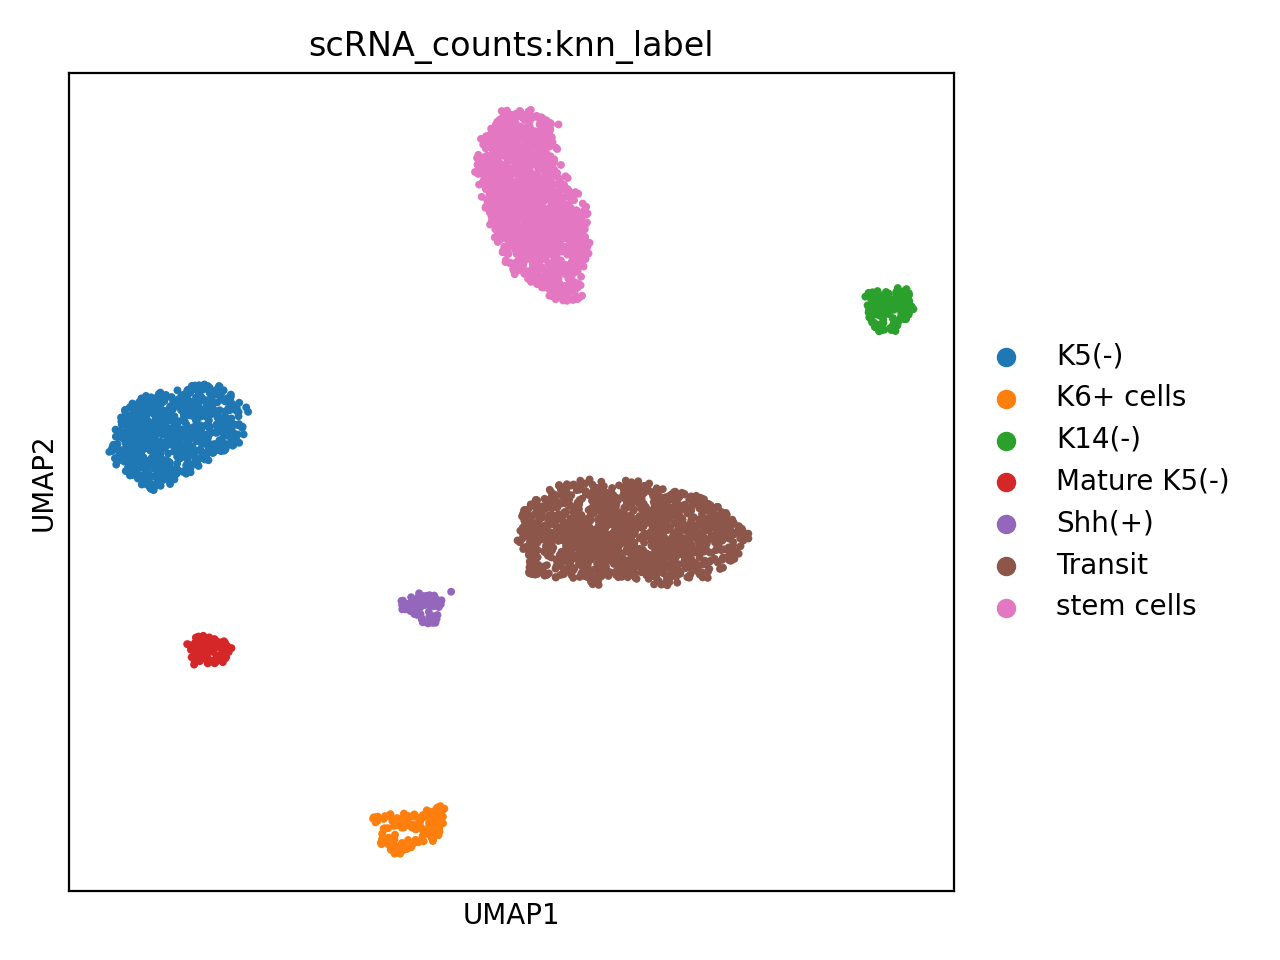

In [24]:
sc.pl.umap(eRegulon_gene_AUC, color = "scRNA_counts:knn_label",save="_reduction.pdf")

In [11]:
from scenicplus.RSS import (regulon_specificity_scores, plot_rss)

In [12]:
rss = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:knn_label",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)

In [146]:
rss

,Atf2_direct_+/+_(29g),Atf2_direct_+/-_(71g),Atf3_direct_+/+_(961g),Atf3_direct_+/-_(237g),Atf3_direct_-/-_(50g),Atf4_direct_+/+_(106g),Atf4_direct_+/-_(13g),Bach1_direct_+/+_(146g),Bach2_direct_+/+_(194g),Cebpb_direct_+/+_(279g),...,Zfp148_extended_+/-_(511g),Zfp207_extended_+/+_(138g),Zfp219_extended_+/+_(40g),Zfp398_extended_+/+_(10g),Zfp407_extended_+/+_(20g),Zfp637_extended_+/-_(15g),Zfp64_extended_+/-_(69g),Zfp704_extended_+/-_(203g),Zfp740_extended_+/-_(22g),Zfp770_extended_+/-_(11g)
K14(-),0.209310,0.206259,0.202661,0.200996,0.240457,0.208888,0.178328,0.208782,0.202304,0.234772,...,0.209088,0.209650,0.204852,0.167445,0.214654,0.180046,0.208577,0.201731,0.167445,NaN
K5(-),0.338052,0.321556,0.375051,0.379486,0.187801,0.350706,0.207437,0.336536,0.338832,0.323156,...,0.344466,0.341615,0.386164,0.167445,0.168283,0.200700,0.347292,0.317510,0.170545,NaN
K6+ cells,0.216805,0.206918,0.230248,0.225088,0.187716,0.221947,0.279971,0.224873,0.209206,0.259921,...,0.214728,0.216481,0.213424,0.167445,0.177722,0.169662,0.218895,0.205973,0.167445,NaN
Mature K5(-),0.202668,0.199604,0.217444,0.215345,0.169752,0.201880,0.338852,0.209195,0.194741,0.208418,...,0.204701,0.198446,0.230572,0.167445,0.175224,0.171044,0.201181,0.202047,0.167445,NaN
Shh(+),0.195947,0.194944,0.205840,0.202403,0.172875,0.198462,0.292786,0.208163,0.197843,0.202232,...,0.197701,0.195999,0.181591,0.167445,0.192457,0.180154,0.199324,0.198202,0.167445,NaN
Transit,0.435750,0.418381,0.461086,0.454458,0.328199,0.447997,0.295493,0.456021,0.457549,0.446022,...,0.441087,0.437332,0.397245,0.169340,0.215074,0.310916,0.448476,0.451792,0.167445,NaN
stem cells,0.459278,0.496615,0.381197,0.391602,0.658144,0.433282,0.189607,0.425102,0.447143,0.411578,...,0.447301,0.457679,0.430315,0.167445,0.455280,0.526638,0.437923,0.463691,0.167445,NaN


In [90]:
rss.to_csv("../result/regulation/20241221_scenicplus/20241221_rss_table.csv")

In [87]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon
from math import ceil, floor
import matplotlib.pyplot as plt
import matplotlib
from typing import List, Tuple, Union
from adjustText import adjust_text
from mudata import MuData
def plot_rss(data_matrix: pd.DataFrame,
             top_n: int = 5,
             selected_groups: List[str] = None,
             num_columns: int = 1,
             figsize: Tuple[float, float] = (6.4, 4.8),
             fontsize: int = 12,
             save: str = None,
             specific_regulons: List[str] = None):
    """
    Plot RSS values per group

    Parameters
    ---------
    data_matrix: `class::pd.DataFrame`
        A pandas dataframe with RSS scores per variable.
    top_n: int, optional
        Number of top eRegulons to highlight.
    selected_groups: List, optional
        Groups to plot. Default: None (all)
    num_columns: int, optional
        Number of columns for multiplotting
    figsize: tuple, optional
        Size of the figure. If num_columns is 1, this is the size for each figure;
        if num_columns is above 1, this is the overall size of the figure (if keeping
        default, it will be the size of each subplot in the figure). Default: (6.4, 4.8)
    fontsize: int, optional
        Size of the eRegulons names in plot.
    save: str, optional
        Path to save plot. Default: None.
    """

    if selected_groups is None:
        cats = sorted(data_matrix.index.tolist())
    else:
        cats = selected_groups

    if num_columns > 1:
        num_rows = int(np.ceil(len(cats) / num_columns))
        figsize = (figsize[0] * num_columns, figsize[1] * num_rows)
        i = 1
        fig = plt.figure(figsize=figsize)

    pdf = None
    if (save is not None) & (num_columns == 1):
        pdf = matplotlib.backends.backend_pdf.PdfPages(save)

    for c in cats:
        x = data_matrix.T[c]
        if num_columns > 1:
            ax = fig.add_subplot(num_rows, num_columns, i)
            i = i + 1
        else:
            fig = plt.figure(figsize=figsize)
            ax = plt.axes()
        _plot_rss_internal(data_matrix, c, top_n=top_n, max_n=None, ax=ax,specific_regulons=specific_regulons)
        ax.set_ylim(x.min()-(x.max()-x.min())*0.05,
                    x.max()+(x.max()-x.min())*0.05)
        for t in ax.texts:
            t.set_fontsize(fontsize)
        ax.set_ylabel('')
        ax.set_xlabel('')
        adjust_text(ax.texts)
        if num_columns == 1:
            fig.text(0.5, 0.0, 'eRegulon rank', ha='center',
                     va='center', size='x-large')
            fig.text(0.00, 0.5, 'eRegulon specificity score (eRSS)',
                     ha='center', va='center', rotation='vertical', size='x-large')
            plt.tight_layout()
            plt.rcParams.update({
                'figure.autolayout': True,
                'figure.titlesize': 'large',
                'axes.labelsize': 'medium',
                'axes.titlesize': 'large',
                'xtick.labelsize': 'medium',
                'ytick.labelsize': 'medium'
            })
            if save is not None:
                pdf.savefig(fig, bbox_inches='tight')
            plt.show()

    if num_columns > 1:
        fig.text(0.5, 0.0, 'eRegulon rank', ha='center',
                 va='center', size='x-large')
        fig.text(0.00, 0.5, 'eRegulon specificity score (eRSS)',
                 ha='center', va='center', rotation='vertical', size='x-large')
        plt.tight_layout()
        plt.rcParams.update({
            'figure.autolayout': True,
            'figure.titlesize': 'large',
            'axes.labelsize': 'medium',
            'axes.titlesize': 'large',
            'xtick.labelsize': 'medium',
            'ytick.labelsize': 'medium'
        })
        if save is not None:
            fig.savefig(save, bbox_inches='tight')
        plt.show()
    if (save is not None) & (num_columns == 1):
        pdf = pdf.close()
def _plot_rss_internal(rss, cell_type, top_n=5, max_n=None, ax=None, specific_regulons=None):
    """
    Helper function to plot RSS

    Parameters
    ----------
    rss: pd.DataFrame
        RSS values dataframe
    cell_type: str
        Cell type to plot
    top_n: int
        Number of top regulons to annotate
    max_n: int
        Maximum number of points to plot
    ax: matplotlib.axes
        Axes to plot on
    specific_regulons: List[str]
        List of specific regulon names to annotate, regardless of their rank
    """
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(4, 4))
    if max_n is None:
        max_n = rss.shape[1]
    data = rss.T[cell_type].sort_values(ascending=False)[0:max_n]
    ax.plot(np.arange(len(data)), data, '.')
    ax.set_ylim([floor(data.min() * 100.0) / 100.0,
                ceil(data.max() * 100.0) / 100.0])
    ax.set_title(cell_type)
    ax.set_xticklabels([])

    # Define fonts for different types of annotations
    top_font = {'color': 'red', 'weight': 'normal'}
    specific_font = {'color': 'red', 'weight': 'normal'}

    # Annotate top N regulons
    for idx, (regulon_name, rss_val) in enumerate(
        zip(data[0:top_n].index, data[0:top_n].values)):
        if specific_regulons is None or regulon_name not in specific_regulons:
            ax.plot([idx, idx], [rss_val, rss_val], 'r.')
            ax.text(
                idx + (max_n / 25),
                rss_val,
                regulon_name,
                fontdict=top_font,
                horizontalalignment='left',
                verticalalignment='center',
            )

    # Annotate specific regulons
    if specific_regulons is not None:
        for regulon_name in specific_regulons:
            if regulon_name in data.index:
                idx = data.index.get_loc(regulon_name)
                rss_val = data[regulon_name]
                ax.plot([idx, idx], [rss_val, rss_val], 'r.')
                ax.text(
                    idx + (max_n / 25),
                    rss_val,
                    regulon_name,
                    fontdict=specific_font,
                    horizontalalignment='left',
                    verticalalignment='center',
                )

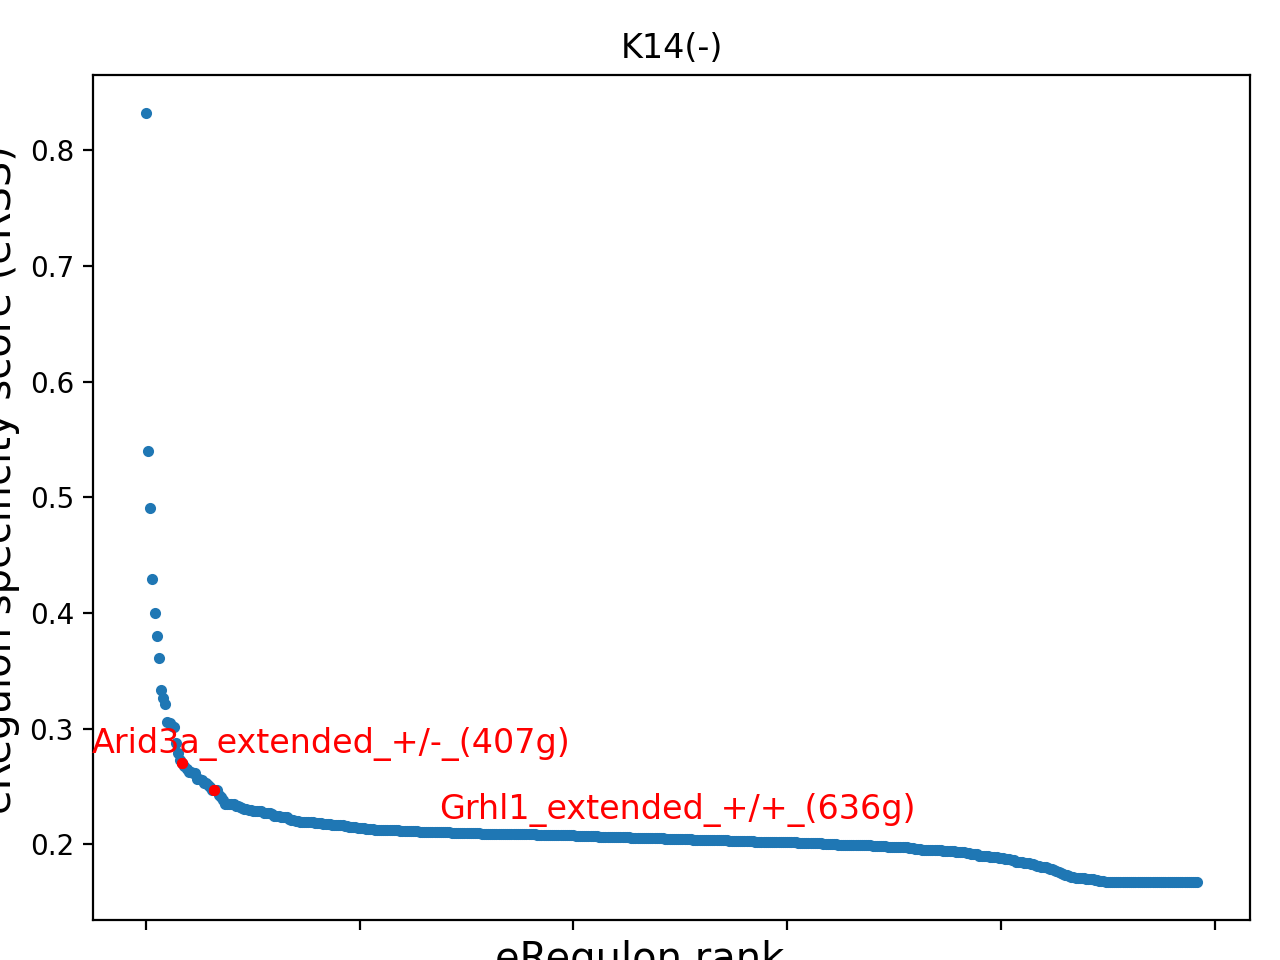

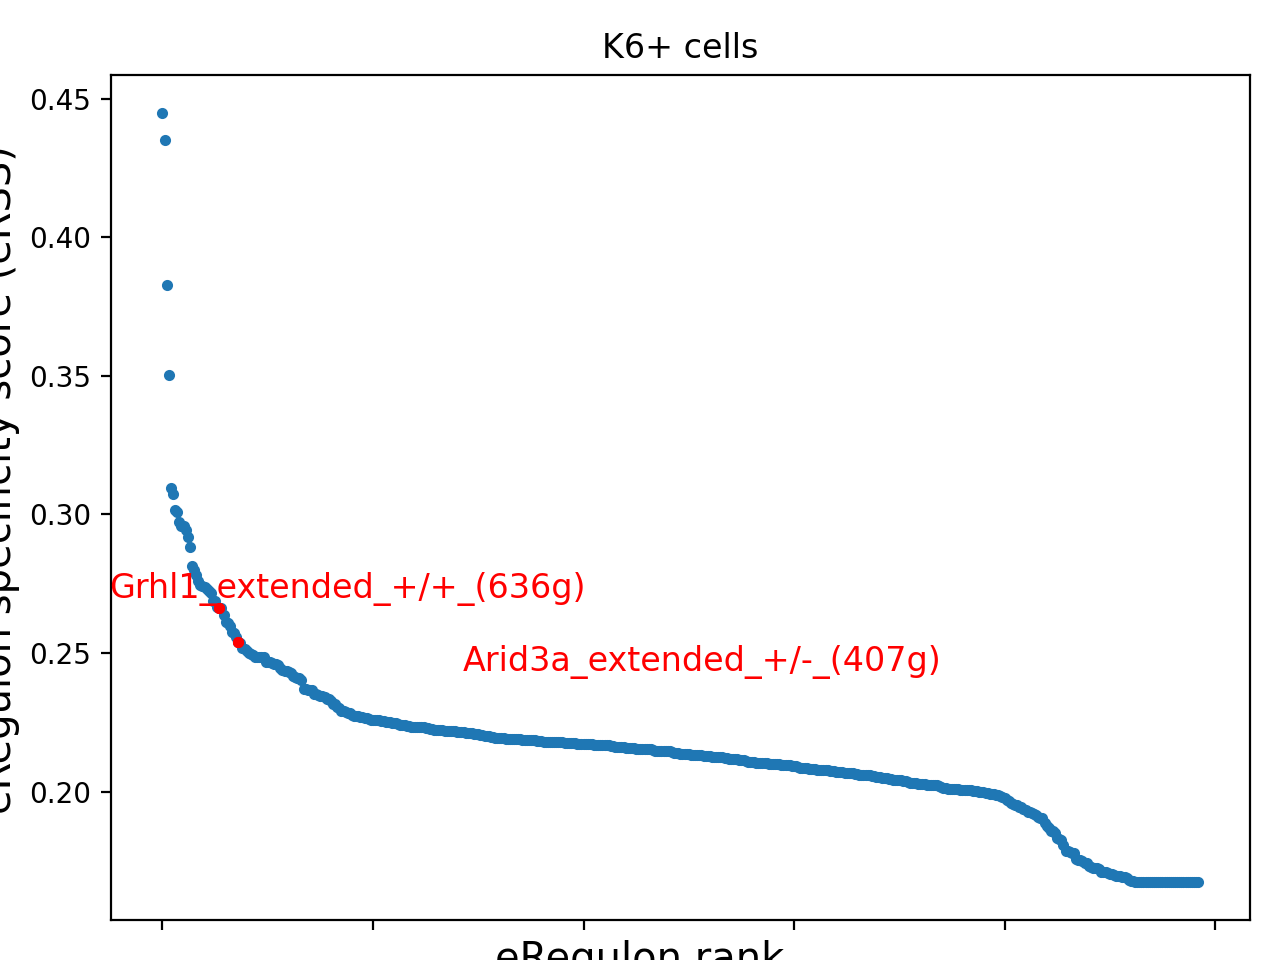

In [88]:
plot_rss(
    data_matrix = rss_k14,
    top_n = 0,specific_regulons=["Arid3a_extended_+/-_(407g)","Grhl1_extended_+/+_(636g)"],
    save="../result/regulation/20241221_scenicplus/regulon_rss_highlight.pdf"
)

In [78]:
rss_k14 = rss.iloc[[0,2]]

In [79]:
rss_k14

,Atf2_direct_+/+_(29g),Atf2_direct_+/-_(71g),Atf3_direct_+/+_(961g),Atf3_direct_+/-_(237g),Atf3_direct_-/-_(50g),Atf4_direct_+/+_(106g),Atf4_direct_+/-_(13g),Bach1_direct_+/+_(146g),Bach2_direct_+/+_(194g),Cebpb_direct_+/+_(279g),...,Zfp148_extended_+/-_(511g),Zfp207_extended_+/+_(138g),Zfp219_extended_+/+_(40g),Zfp398_extended_+/+_(10g),Zfp407_extended_+/+_(20g),Zfp637_extended_+/-_(15g),Zfp64_extended_+/-_(69g),Zfp704_extended_+/-_(203g),Zfp740_extended_+/-_(22g),Zfp770_extended_+/-_(11g)
K14(-),0.209310,0.206259,0.202661,0.200996,0.240457,0.208888,0.178328,0.208782,0.202304,0.234772,...,0.209088,0.209650,0.204852,0.167445,0.214654,0.180046,0.208577,0.201731,0.167445,NaN
K6+ cells,0.216805,0.206918,0.230248,0.225088,0.187716,0.221947,0.279971,0.224873,0.209206,0.259921,...,0.214728,0.216481,0.213424,0.167445,0.177722,0.169662,0.218895,0.205973,0.167445,NaN


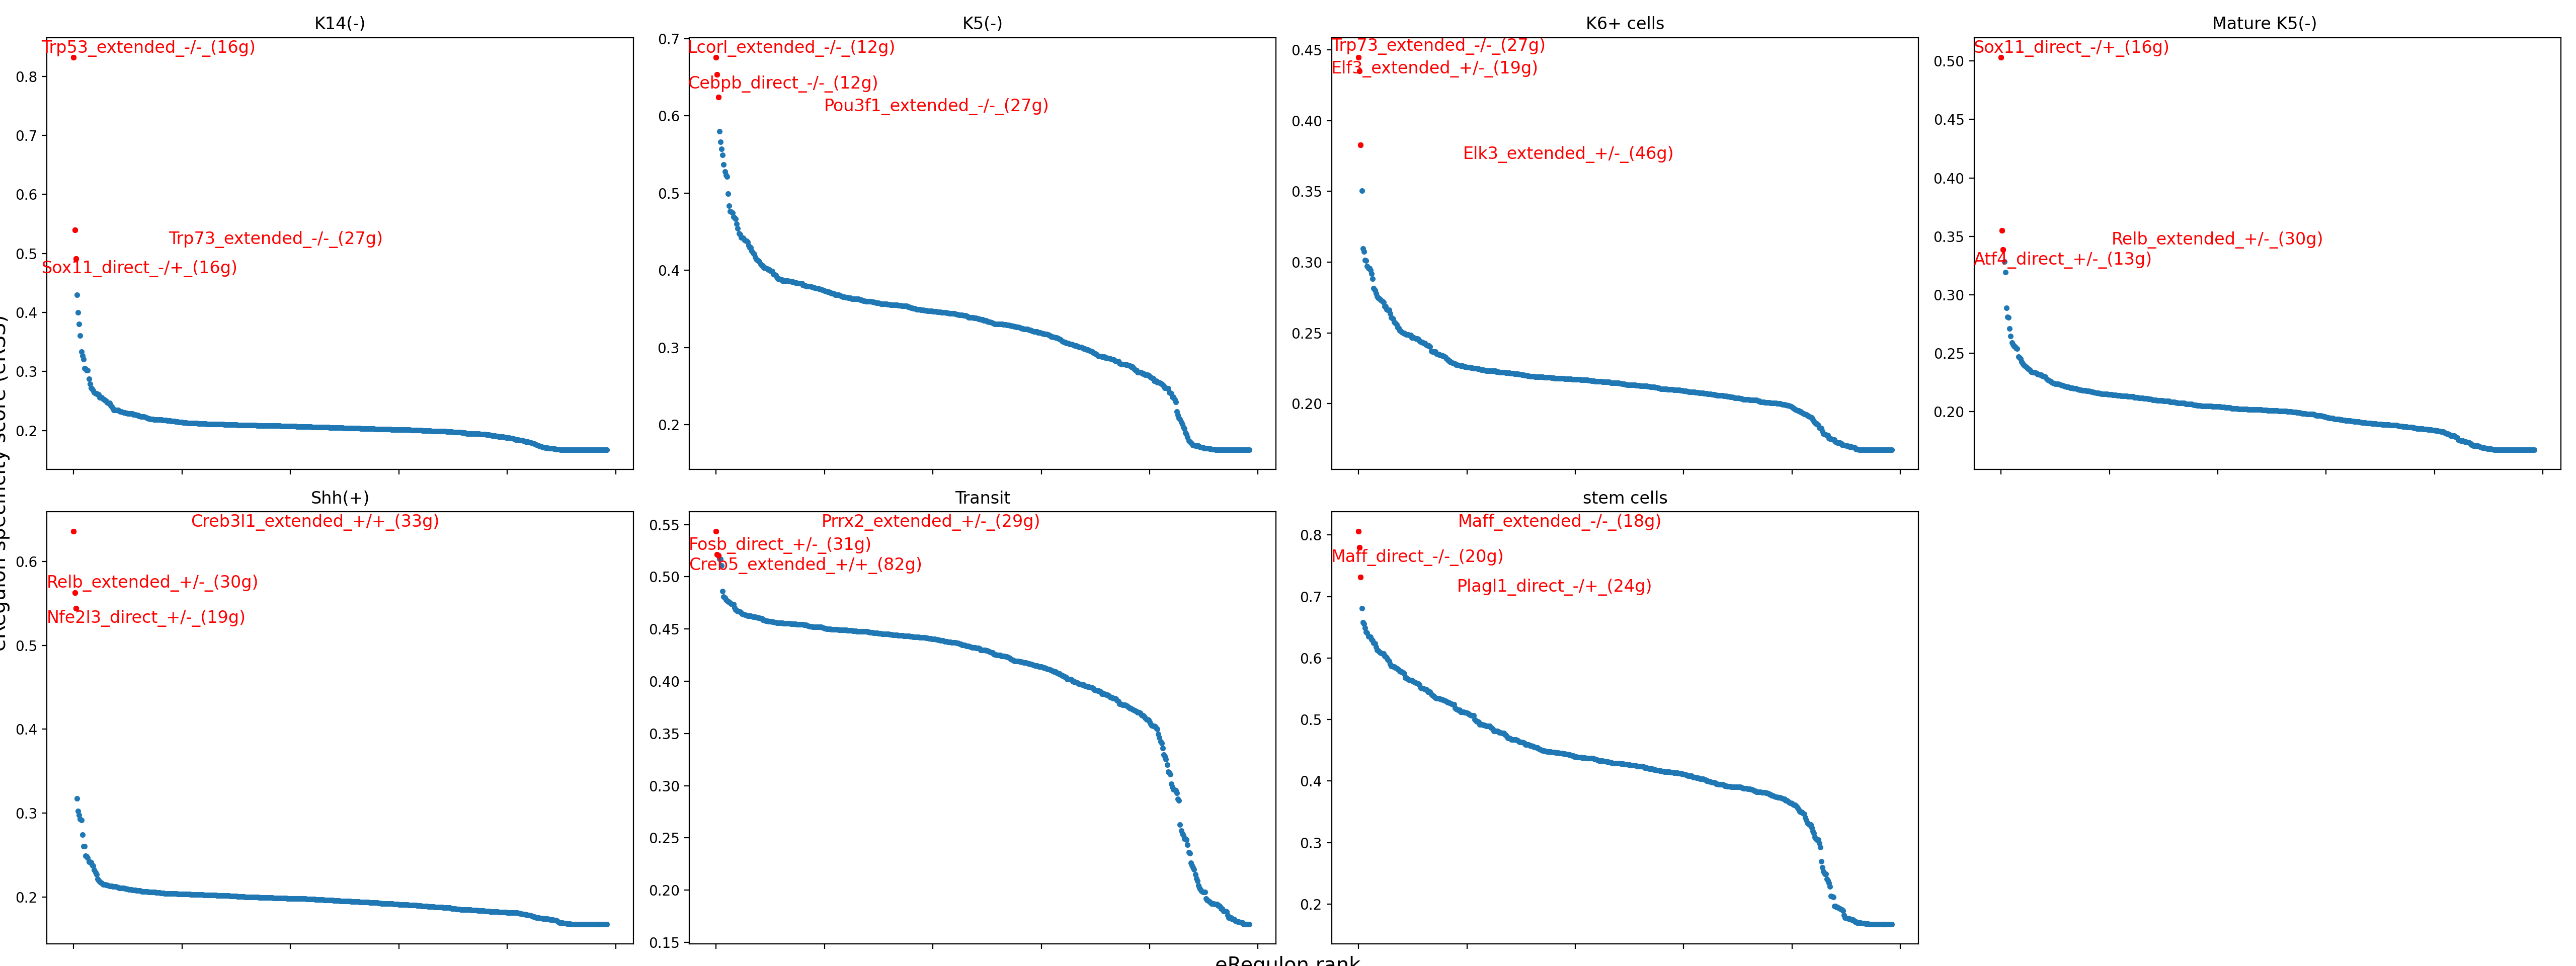

In [60]:
plot_rss(
    data_matrix = rss,
    top_n = 3,
    num_columns = 4,save="../result/regulation/20241221_scenicplus/regulon_rss.pdf"
)

In [59]:
rss.loc["K14(-)"].sort_values(ascending=False)[0:30]

Trp53_extended_-/-_(16g)      0.832324
Trp73_extended_-/-_(27g)      0.540119
Sox11_direct_-/+_(16g)        0.490955
Hey1_extended_+/-_(32g)       0.429697
Elf1_direct_+/+_(16g)         0.400084
Sox6_extended_-/-_(28g)       0.380143
Bcl11a_extended_-/+_(152g)    0.361268
Sox5_direct_+/-_(71g)         0.333542
Snai2_direct_-/+_(66g)        0.326438
Snai2_extended_-/+_(127g)     0.321148
Elf1_direct_+/-_(93g)         0.305510
Grhl3_extended_+/-_(31g)      0.304512
Scmh1_extended_+/+_(10g)      0.302348
Trp63_extended_-/-_(127g)     0.301712
Ikzf2_extended_+/-_(287g)     0.287488
Heyl_extended_+/-_(138g)      0.279014
Zbtb7b_extended_+/+_(28g)     0.272634
Arid3a_extended_+/-_(407g)    0.270508
Trp63_extended_-/+_(178g)     0.267697
Grhl3_extended_+/+_(462g)     0.264610
Nfat5_direct_+/+_(180g)       0.262696
Nfat5_extended_+/+_(180g)     0.262696
Elf3_extended_+/-_(19g)       0.261335
Atf3_extended_-/-_(76g)       0.261264
Ikzf2_extended_+/+_(289g)     0.256415
Elf1_extended_+/-_(167g) 

/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


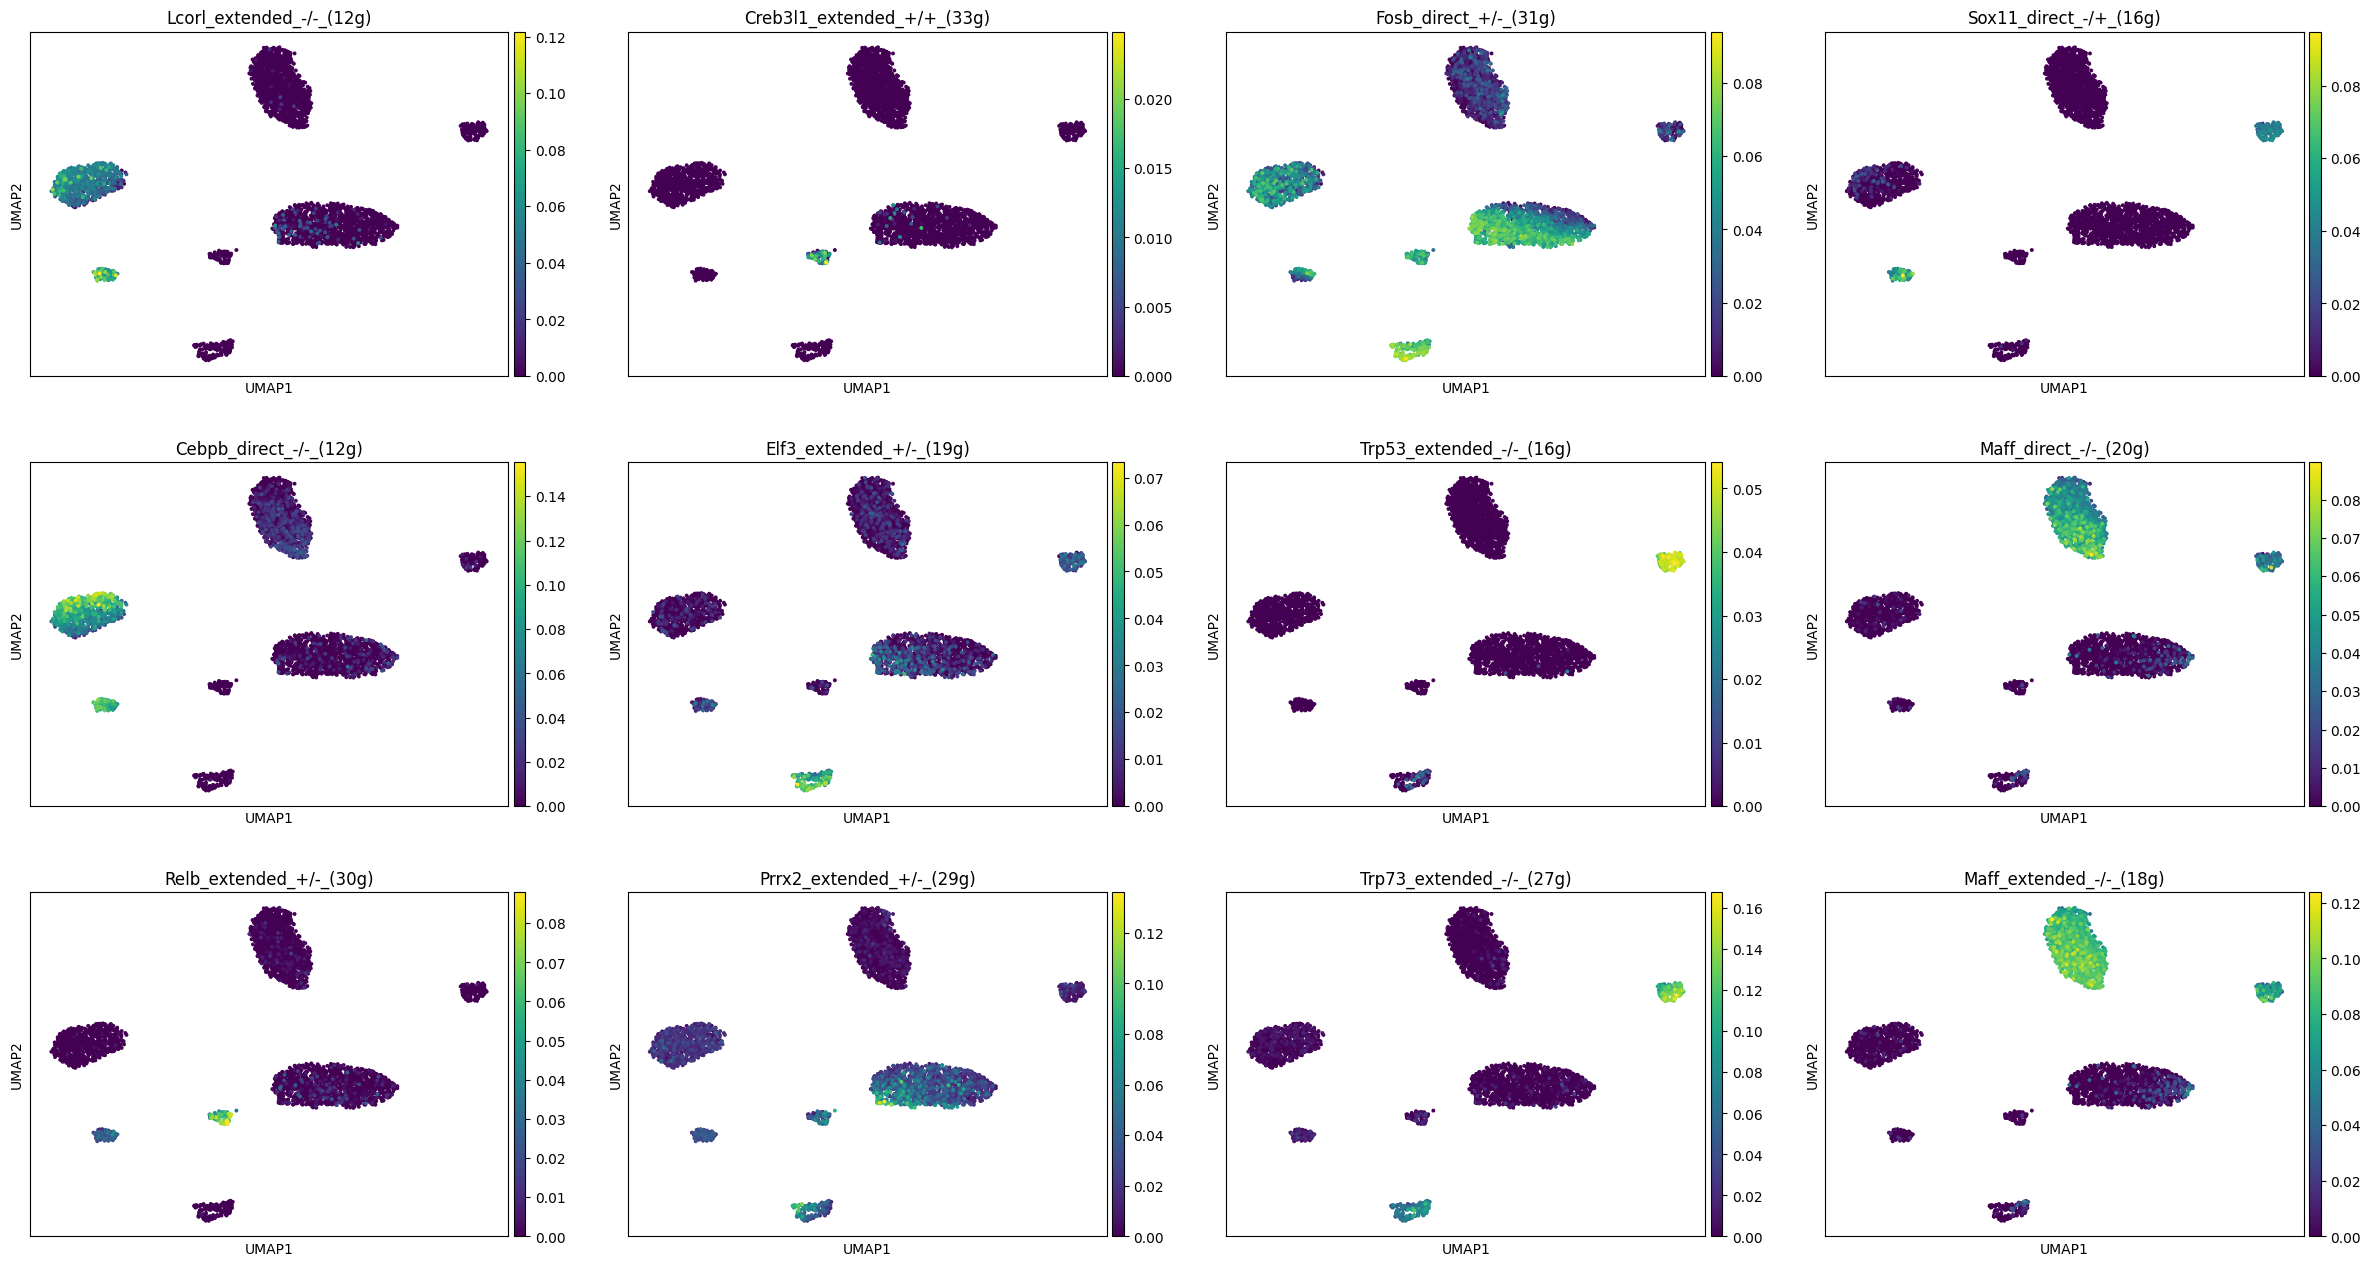

In [17]:
sc.pl.umap(eRegulon_gene_AUC, color = list(set([x for xs in [rss.loc[ct].sort_values(ascending=False)[0:2].index for ct in rss.index] for x in xs ])))

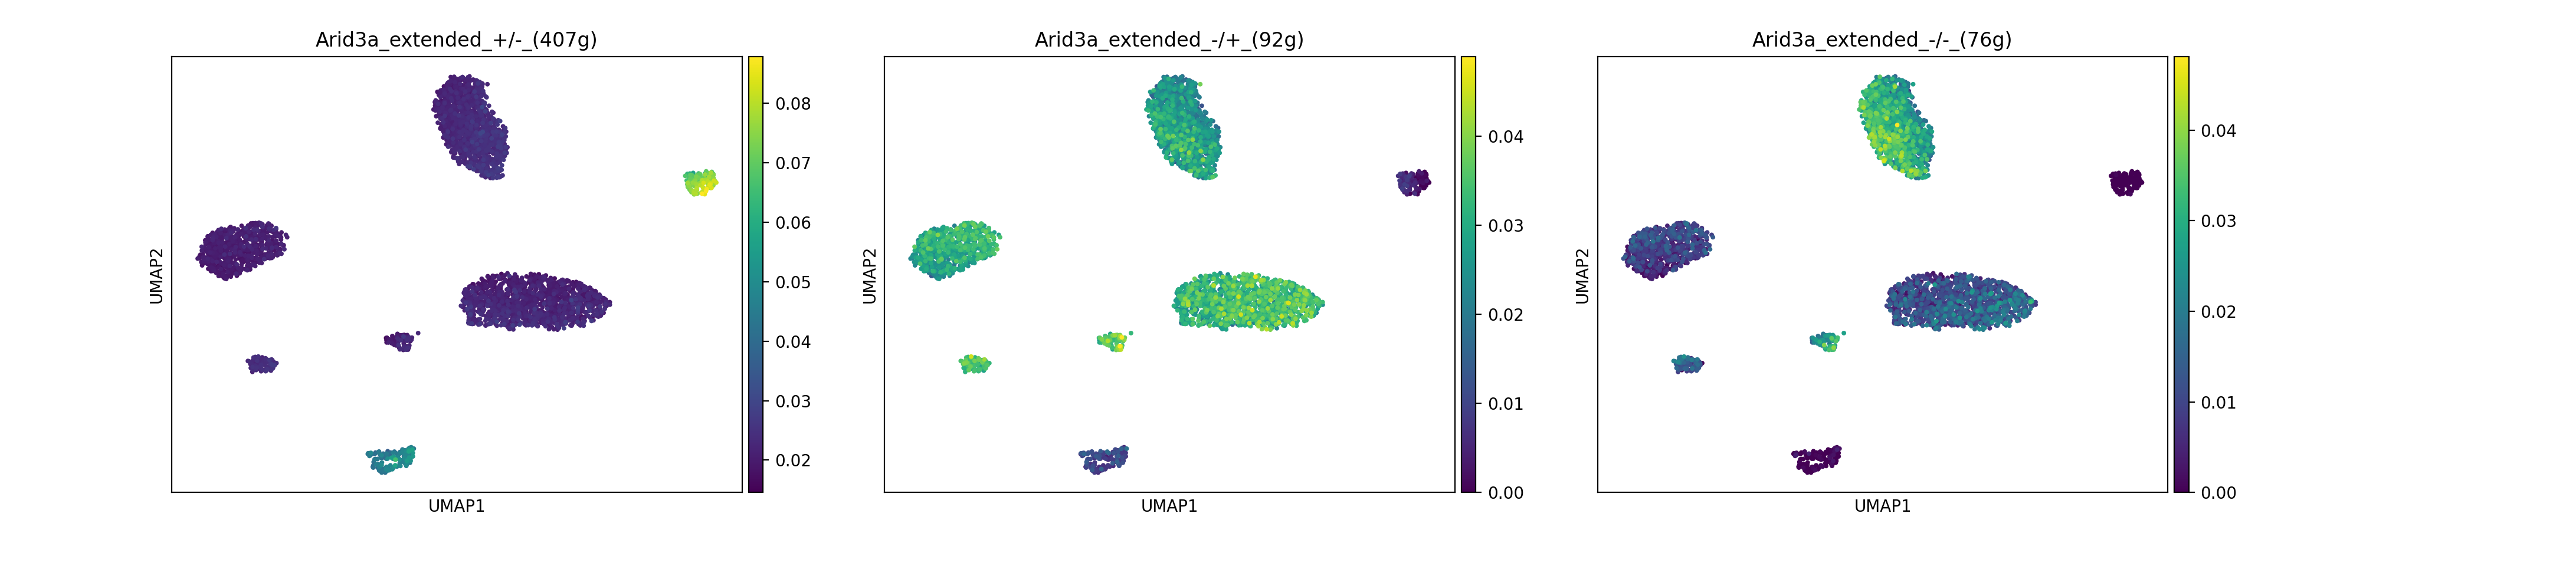

In [46]:
sc.pl.umap(eRegulon_gene_AUC, color= ["Arid3a_extended_+/-_(407g)",'Arid3a_extended_-/+_(92g)', 'Arid3a_extended_-/-_(76g)'])

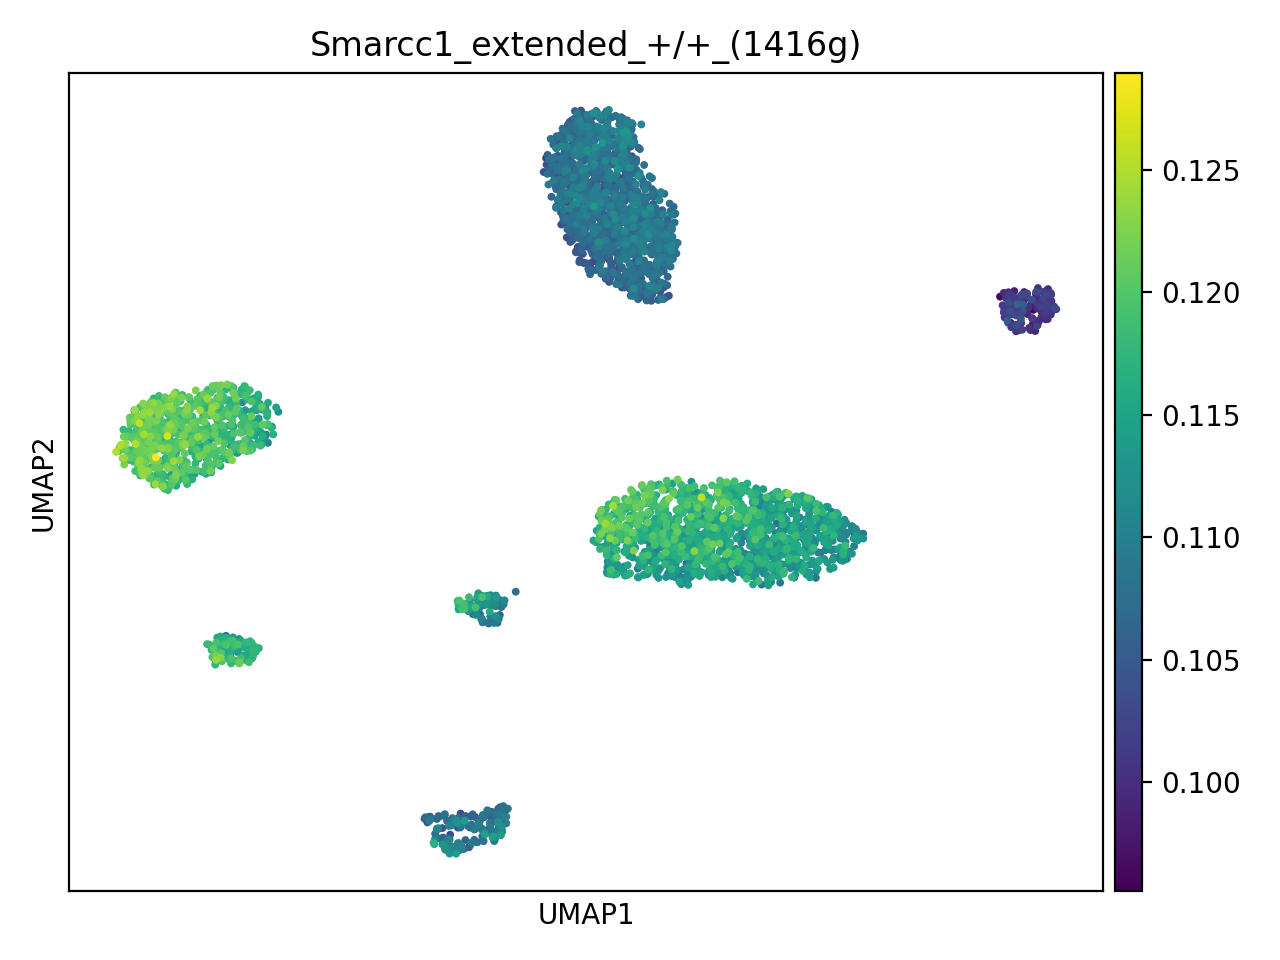

In [54]:
sc.pl.umap(eRegulon_gene_AUC, color= ["Smarcc1_extended_+/+_(1416g)"])

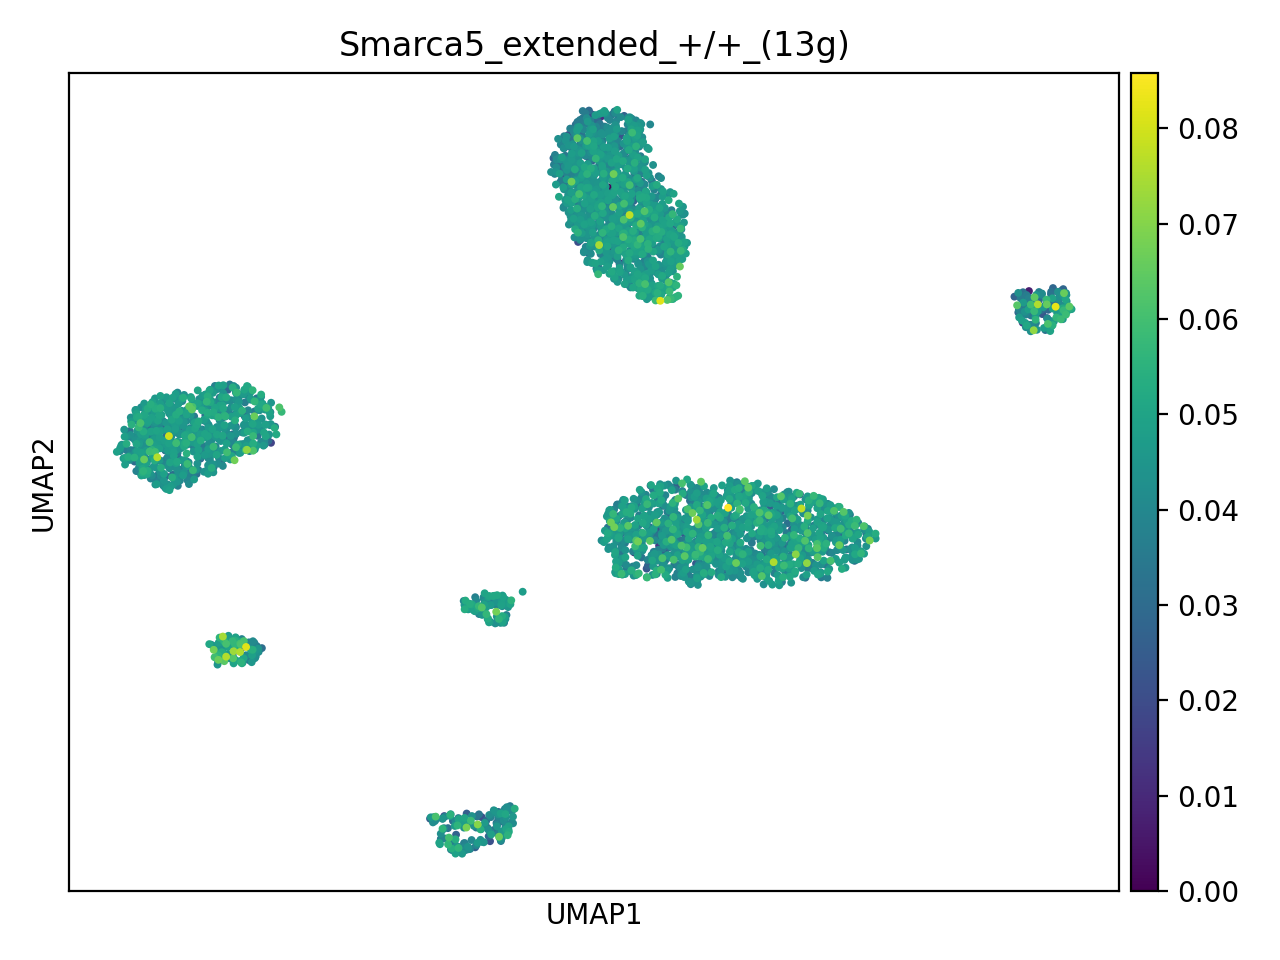

In [55]:
sc.pl.umap(eRegulon_gene_AUC, color= ["Smarca5_extended_+/+_(13g)"])

In [ ]:
sc.pl.umap(eRegulon_gene_AUC, color= ["Arid3a_extended_+/-_(407g)",'Arid3a_extended_-/+_(92g)', 'Arid3a_extended_-/-_(76g)'])

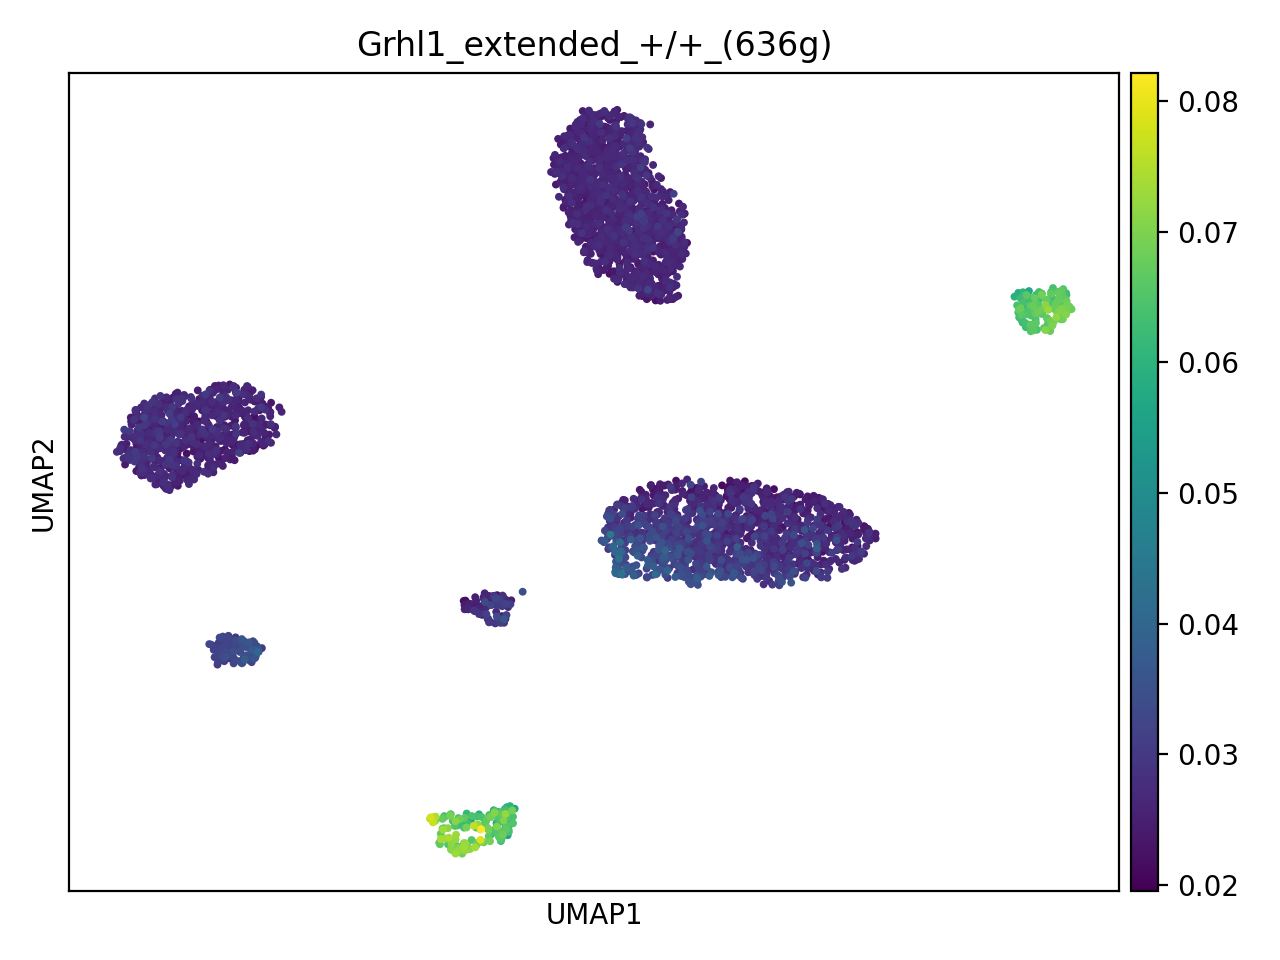

In [51]:
sc.pl.umap(eRegulon_gene_AUC, color= ["Grhl1_extended_+/+_(636g)"])

In [20]:
!mkdir ../result/regulation
!mkdir ../result/regulation/20241221_scenicplus

In [120]:
scplus_mdata

MuData object with n_obs × n_vars = 3756 × 520660
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	3756 x 23143
      obs:	'knn_label'
    scATAC_counts:	3756 x 496513
      obs:	'knn_label'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	3756 x 193
    direct_region_based_AUC:	3756 x 193
    extended_gene_based_AUC:	3756 x 309
    extended_region_based_AUC:	3756 x 309

In [127]:
from scenicplus.plotting.dotplot import generate_dotplot_df

In [130]:
sizeMat

,Atf2_direct_+/+_(29g),Atf2_direct_+/-_(71g),Atf3_direct_+/+_(961g),Atf3_direct_+/-_(237g),Atf3_direct_-/-_(50g),Atf4_direct_+/+_(106g),Atf4_direct_+/-_(13g),Bach1_direct_+/+_(146g),Bach2_direct_+/+_(194g),Cebpb_direct_+/+_(279g),...,Tgif1_direct_+/-_(239g),Thra_direct_+/+_(73g),Thrb_direct_+/+_(40g),Trp63_direct_+/+_(98g),Uncx_direct_+/+_(19g),Uncx_direct_+/-_(14g),Yy1_direct_+/-_(32g),Zbtb1_direct_+/-_(26g),Zfp148_direct_+/-_(433g),Zfp740_direct_+/-_(22g)
Cell,,,,,,,,,,,,,,,,,,,,,
K14(-)_0,0.100915,0.036179,0.034535,0.044174,0.047640,0.132614,0.000000,0.018482,0.030607,0.080715,...,0.068533,0.135352,0.136711,0.052167,0.0,0.0,0.185609,0.0,0.049712,0.0
K14(-)_1,0.100080,0.037506,0.031037,0.043788,0.055022,0.134905,0.015425,0.017150,0.032135,0.072270,...,0.065492,0.135104,0.142135,0.058746,0.0,0.0,0.203895,0.0,0.048802,0.0
K14(-)_2,0.105207,0.030141,0.031683,0.048153,0.050475,0.131953,0.000000,0.015356,0.030309,0.074501,...,0.063170,0.132878,0.134226,0.049627,0.0,0.0,0.184718,0.0,0.046864,0.0
K14(-)_3,0.106697,0.037762,0.033011,0.045498,0.040691,0.131611,0.000000,0.017606,0.031213,0.077152,...,0.070388,0.134015,0.139067,0.054292,0.0,0.0,0.182746,0.0,0.039830,0.0
K14(-)_4,0.108098,0.041669,0.031422,0.043919,0.069369,0.120530,0.000000,0.015907,0.035383,0.072849,...,0.061637,0.132996,0.130294,0.071182,0.0,0.0,0.184124,0.0,0.050740,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
stem cells_1285,0.111465,0.049594,0.029009,0.047198,0.052982,0.122364,0.000000,0.013776,0.042952,0.036673,...,0.044864,0.127751,0.055920,0.115341,0.0,0.0,0.206434,0.0,0.044080,0.0
stem cells_1286,0.106071,0.054573,0.030404,0.049473,0.047468,0.121492,0.000000,0.015682,0.044587,0.037370,...,0.048643,0.124578,0.061085,0.122017,0.0,0.0,0.214482,0.0,0.048631,0.0
stem cells_1287,0.105743,0.054950,0.027841,0.043427,0.040916,0.130045,0.000000,0.013906,0.041763,0.034628,...,0.048021,0.124862,0.049438,0.111548,0.0,0.0,0.215428,0.0,0.047611,0.0


In [124]:
from scenicplus.plotting.dotplot import heatmap_dotplot
heatmap_dotplot(
    scplus_mudata = scplus_mdata,
    color_modality = "direct_gene_based_AUC",
    size_modality = "direct_region_based_AUC",
    group_variable = "scRNA_counts:knn_label",
    eRegulon_metadata_key = "direct_e_regulon_metadata",
    color_feature_key = "Gene_signature_name",
    size_feature_key = "Region_signature_name",
    feature_name_key = "eRegulon_name",
    sort_data_by = "direct_gene_based_AUC",
    orientation = "horizontal",
    figsize = (25, 5),save="../result/regulation/20241221_scenicplus/regulon_heatmap.pdf"
)


In [128]:
sizeMat = scplus_mdata["direct_gene_based_AUC"].to_df()
colorMat = scplus_mdata["direct_region_based_AUC"].to_df()
group_by = scplus_mdata.obs["scRNA_counts:knn_label"].tolist()
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
size_features = regulon_metadata["Region_signature_name"].tolist()
color_features = regulon_metadata["Gene_signature_name"].tolist()
feature_names = regulon_metadata["eRegulon_name"].tolist()

# Generate dotplot dataframe
dotplot_df = generate_dotplot_df(
    size_matrix=sizeMat,
    color_matrix=colorMat,
    group_by=group_by,
    size_features=size_features,
    color_features=color_features,
    feature_names=feature_names,
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name="knn_label",
    size_name="direct_gene_based_AUC",
    color_name="direct_region_based_AUC",
    feature_name="eRegulon"
)


KeyError: "None of [Index(['Atf2_direct_+/+_(28r)', 'Atf2_direct_+/+_(28r)',\n       'Atf2_direct_+/+_(28r)', 'Atf2_direct_+/+_(28r)',\n       'Atf2_direct_+/+_(28r)', 'Atf2_direct_+/+_(28r)',\n       'Atf2_direct_+/+_(28r)', 'Atf2_direct_+/+_(28r)',\n       'Atf2_direct_+/+_(28r)', 'Atf2_direct_+/+_(28r)',\n       ...\n       'Tfap2a_direct_-/-_(15r)', 'Tfap2a_direct_-/-_(15r)',\n       'Tfap2a_direct_-/-_(15r)', 'Tfap2a_direct_-/-_(15r)',\n       'Tfap2a_direct_-/-_(15r)', 'Tfap2a_direct_-/-_(15r)',\n       'Tfap2a_direct_-/-_(15r)', 'Tfap2a_direct_-/-_(15r)',\n       'Tfap2a_direct_-/-_(15r)', 'Tfap2a_direct_-/-_(15r)'],\n      dtype='object', length=60763)] are in the [columns]"

In [138]:
# First, check the actual column names in your matrices
print("Size matrix columns:", sizeMat.columns[:5])  # Print first 5 columns
print("Color matrix columns:", colorMat.columns[:5])

# Check the feature names you're trying to use
print("Size features (first 5):", size_features[:5])
print("Color features (first 5):", color_features[:5])

# Get the correct feature names from metadata
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
print("Metadata columns:", regulon_metadata.columns)

# Make sure features match exactly
size_features = regulon_metadata["Gene_signature_name"].drop_duplicates().tolist()
color_features = regulon_metadata["Region_signature_name"].drop_duplicates().tolist()
feature_names = regulon_metadata["eRegulon_name"].drop_duplicates().tolist()

# Verify features exist in matrices
common_size_features = [f for f in size_features if f in sizeMat.columns]
common_color_features = [f for f in color_features if f in colorMat.columns]

# Now try generate_dotplot_df with verified features
dotplot_df = generate_dotplot_df(
    size_matrix=sizeMat,
    color_matrix=colorMat,
    group_by=group_by,
    size_features=common_size_features,
    color_features=common_color_features,
    feature_names=feature_names[:len(common_size_features)],  # Make sure lengths match
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name="knn_label",
    size_name="direct_gene_based_AUC",
    color_name="direct_region_based_AUC",
    feature_name="eRegulon"
)

Size matrix columns: Index(['Atf2_direct_+/+_(29g)', 'Atf2_direct_+/-_(71g)',
       'Atf3_direct_+/+_(961g)', 'Atf3_direct_+/-_(237g)',
       'Atf3_direct_-/-_(50g)'],
      dtype='object')
Color matrix columns: Index(['Atf2_direct_+/+_(28r)', 'Atf2_direct_+/-_(72r)',
       'Atf3_direct_+/+_(1976r)', 'Atf3_direct_+/-_(284r)',
       'Atf3_direct_-/-_(73r)'],
      dtype='object')
Size features (first 5): ['Atf2_direct_+/+_(28r)', 'Atf3_direct_+/+_(1976r)', 'Atf4_direct_+/+_(113r)', 'Bach1_direct_+/+_(200r)', 'Bach2_direct_+/+_(345r)']
Color features (first 5): ['Atf2_direct_+/+_(29g)', 'Atf3_direct_+/+_(961g)', 'Atf4_direct_+/+_(106g)', 'Bach1_direct_+/+_(146g)', 'Bach2_direct_+/+_(194g)']
Metadata columns: Index(['Region', 'Gene', 'importance_R2G', 'rho_R2G', 'importance_x_rho',
       'importance_x_abs_rho', 'TF', 'is_extended', 'eRegulon_name',
       'Gene_signature_name', 'Region_signature_name', 'importance_TF2G',
       'regulation', 'rho_TF2G', 'triplet_rank'],
      dtype='

In [144]:
sizeMat = scplus_mdata["extended_gene_based_AUC"].to_df()
colorMat = scplus_mdata["extended_region_based_AUC"].to_df()
group_by = scplus_mdata.obs["scRNA_counts:knn_label"].tolist()
regulon_metadata = scplus_mdata.uns["direct_e_regulon_metadata"]
size_features = regulon_metadata["Region_signature_name"].tolist()
color_features = regulon_metadata["Gene_signature_name"].tolist()
feature_names = regulon_metadata["eRegulon_name"].tolist()
# First, check the actual column names in your matrices
print("Size matrix columns:", sizeMat.columns[:5])  # Print first 5 columns
print("Color matrix columns:", colorMat.columns[:5])

# Check the feature names you're trying to use
print("Size features (first 5):", size_features[:5])
print("Color features (first 5):", color_features[:5])

# Get the correct feature names from metadata
regulon_metadata = scplus_mdata.uns["extended_e_regulon_metadata"]
print("Metadata columns:", regulon_metadata.columns)

# Make sure features match exactly
size_features = regulon_metadata["Gene_signature_name"].drop_duplicates().tolist()
color_features = regulon_metadata["Region_signature_name"].drop_duplicates().tolist()
feature_names = regulon_metadata["eRegulon_name"].drop_duplicates().tolist()

# Verify features exist in matrices
common_size_features = [f for f in size_features if f in sizeMat.columns]
common_color_features = [f for f in color_features if f in colorMat.columns]

# Now try generate_dotplot_df with verified features
dotplot_df_extend = generate_dotplot_df(
    size_matrix=sizeMat,
    color_matrix=colorMat,
    group_by=group_by,
    size_features=common_size_features,
    color_features=common_color_features,
    feature_names=feature_names[:len(common_size_features)],  # Make sure lengths match
    scale_size_matrix=True,
    scale_color_matrix=True,
    group_name="knn_label",
    size_name="extended_gene_based_AUC",
    color_name="extended_region_based_AUC",
    feature_name="eRegulon"
)

Size matrix columns: Index(['Acaa1b_extended_+/-_(93g)', 'Arid3a_extended_+/-_(407g)',
       'Arid3a_extended_-/+_(92g)', 'Arid3a_extended_-/-_(76g)',
       'Atf3_extended_+/+_(902g)'],
      dtype='object')
Color matrix columns: Index(['Acaa1b_extended_+/-_(131r)', 'Arid3a_extended_+/-_(722r)',
       'Arid3a_extended_-/+_(147r)', 'Arid3a_extended_-/-_(110r)',
       'Atf3_extended_+/+_(1957r)'],
      dtype='object')
Size features (first 5): ['Atf2_direct_+/+_(28r)', 'Atf2_direct_+/+_(28r)', 'Atf2_direct_+/+_(28r)', 'Atf2_direct_+/+_(28r)', 'Atf2_direct_+/+_(28r)']
Color features (first 5): ['Atf2_direct_+/+_(29g)', 'Atf2_direct_+/+_(29g)', 'Atf2_direct_+/+_(29g)', 'Atf2_direct_+/+_(29g)', 'Atf2_direct_+/+_(29g)']
Metadata columns: Index(['Region', 'Gene', 'importance_R2G', 'rho_R2G', 'importance_x_rho',
       'importance_x_abs_rho', 'TF', 'is_extended', 'eRegulon_name',
       'Gene_signature_name', 'Region_signature_name', 'importance_TF2G',
       'regulation', 'rho_TF2G', 'tri

In [157]:
dotplot_df.columns = ['knn_label', 'region_based_AUC', 'eRegulon',
       'gene_based_AUC']
dotplot_df_extend.columns = ['knn_label', 'region_based_AUC', 'eRegulon',
       'gene_based_AUC']

In [158]:
dotplot_concat = pd.concat([dotplot_df,dotplot_df_extend],axis=0)

,knn_label,region_based_AUC,eRegulon,gene_based_AUC
0,K14(-),0.219605,Atf2_direct_+/+,0.548438
1,K14(-),0.293792,Atf3_direct_+/+,0.091058
2,K14(-),0.374857,Atf4_direct_+/+,0.223701
3,K14(-),0.229682,Bach1_direct_+/+,0.124075
4,K14(-),0.220010,Bach2_direct_+/+,0.118759
...,...,...,...,...
2116,stem cells,0.004326,Tead2_extended_-/-,1.000000
2117,stem cells,0.000000,Thrb_extended_-/-,1.000000
2118,stem cells,0.610341,Trp53_extended_-/-,0.000000
2119,stem cells,1.000000,Trp63_extended_-/-,0.000000


In [255]:
df = rss.T

In [332]:
columnOrder = ['K14(-)','K6+ cells','Mature K5(-) ','K5(-)','Shh(+)','Transit','stem cells']


In [361]:
set(dotplot_concat_filter_top3_sorted["eRegulon"])

{'Arid3a_extended_+/-',
 'Atf4_direct_+/-',
 'Creb3l1_extended_+/+',
 'Creb5_extended_+/+',
 'E2f7_direct_+/+',
 'Elf1_direct_+/+',
 'Elf3_extended_+/-',
 'Elk3_extended_+/-',
 'Fosb_direct_+/-',
 'Foxq1_extended_+/-',
 'Hey1_extended_+/-',
 'Irx4_extended_+/-',
 'Nfe2l3_direct_+/-',
 'Nr6a1_extended_+/+',
 'Prrx2_extended_+/-',
 'Relb_extended_+/-',
 'Runx2_extended_+/+',
 'Sox21_direct_+/+',
 'Sox5_direct_+/-',
 'Tcf7l2_extended_+/+'}

In [366]:
common_elements = [x for x in cleaned_list_top3 if x in dotplot_concat_filter_top3['eRegulon'].values]


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 289.0377546222578
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/3832536268.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


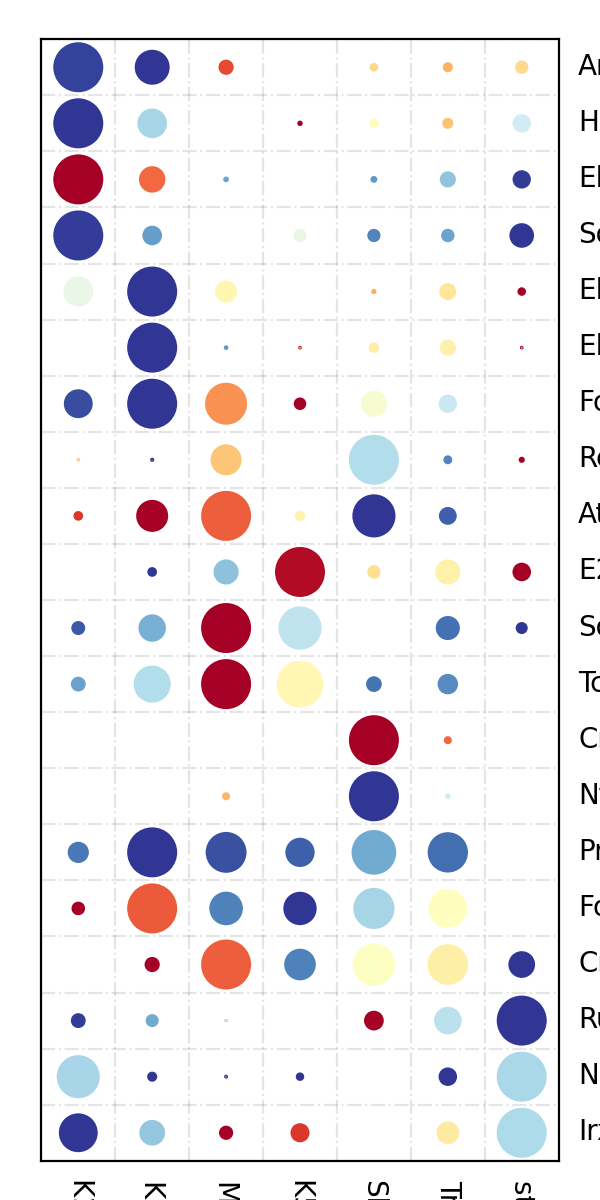

In [369]:
import pandas as pd

# Assuming your dataframe is called 'df'
result = {}
df_activators = df[df.index.str.contains('_\+/')]  # This keeps rows where eRegulon contains '+/'
df_activators = df_activators.loc[:,columnOrder]
for column in df_activators.columns:
    # Sort values in descending order and get top 5
    top_5 = df_activators[column].sort_values(ascending=False).head(3)
    result[column] = {
        'regulons': list(top_5.index),
        'values': list(top_5.values)
    }

regulonList_top3 = []
for column, data in result.items():
    for regulon, value in zip(data['regulons'], data['values']):
        if regulon not in regulonList_top3:
            regulonList_top3.append(regulon)
cleaned_list_top3 = [x.split('_(')[0] for x in regulonList_top3]
cleaned_list_top3 = ["Arid3a_extended_+/-"] + cleaned_list_top3
cleaned_list_top3 
dotplot_concat_filter_top3 = dotplot_concat[dotplot_concat.eRegulon.isin(cleaned_list_top3)]

cleaned_list_top3 = [x for x in cleaned_list_top3 if x in dotplot_concat_filter_top3['eRegulon'].values]

dotplot_concat_filter_top3['knn_label'] = pd.Categorical(dotplot_concat_filter_top3['knn_label'], 
                                categories=columnOrder, 
                                ordered=True)
dotplot_concat_filter_top3['eRegulon'] = pd.Categorical(dotplot_concat_filter_top3['eRegulon'], 
                                categories=cleaned_list_top3, 
                                ordered=True)
# Sort the DataFrame
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3.sort_values('eRegulon')
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3_sorted.sort_values('knn_label')

plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=dotplot_concat_filter_top3_sorted,
    x='knn_label',          # Column names
    y='eRegulon',
    value='gene_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=False,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()
plt.savefig("../result/regulation/20241221_scenicplus/20241225_top3_regulon.pdf",bbox_inches='tight')
plt.show()

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 106.16630105500745
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/1928040637.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


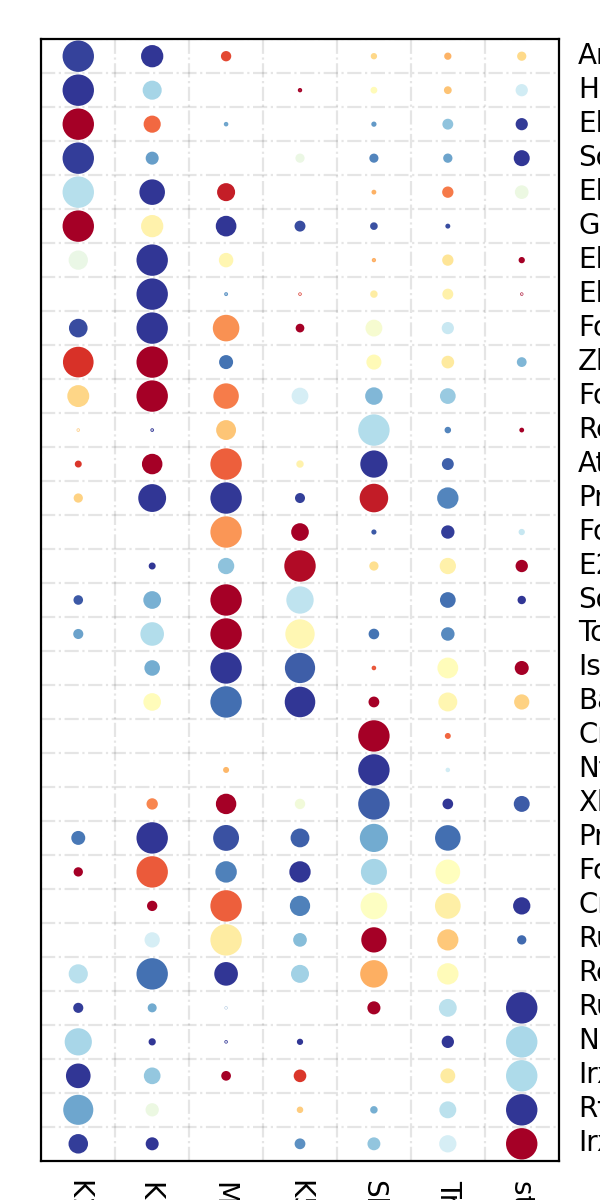

In [370]:
import pandas as pd

# Assuming your dataframe is called 'df'
result = {}
df_activators = df[df.index.str.contains('_\+/')]  # This keeps rows where eRegulon contains '+/'
df_activators = df_activators.loc[:,columnOrder]
for column in df_activators.columns:
    # Sort values in descending order and get top 5
    top_5 = df_activators[column].sort_values(ascending=False).head(5)
    result[column] = {
        'regulons': list(top_5.index),
        'values': list(top_5.values)
    }

regulonList_top3 = []
for column, data in result.items():
    for regulon, value in zip(data['regulons'], data['values']):
        if regulon not in regulonList_top3:
            regulonList_top3.append(regulon)
cleaned_list_top3 = [x.split('_(')[0] for x in regulonList_top3]
cleaned_list_top3 = ["Arid3a_extended_+/-"] + cleaned_list_top3
cleaned_list_top3 
dotplot_concat_filter_top3 = dotplot_concat[dotplot_concat.eRegulon.isin(cleaned_list_top3)]

cleaned_list_top3 = [x for x in cleaned_list_top3 if x in dotplot_concat_filter_top3['eRegulon'].values]

dotplot_concat_filter_top3['knn_label'] = pd.Categorical(dotplot_concat_filter_top3['knn_label'], 
                                categories=columnOrder, 
                                ordered=True)
dotplot_concat_filter_top3['eRegulon'] = pd.Categorical(dotplot_concat_filter_top3['eRegulon'], 
                                categories=cleaned_list_top3, 
                                ordered=True)
# Sort the DataFrame
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3.sort_values('eRegulon')
dotplot_concat_filter_top3_sorted = dotplot_concat_filter_top3_sorted.sort_values('knn_label')

plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=dotplot_concat_filter_top3_sorted,
    x='knn_label',          # Column names
    y='eRegulon',
    value='gene_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=False,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()
plt.savefig("../result/regulation/20241221_scenicplus/20241225_top5_regulon.pdf",bbox_inches='tight')
plt.show()

In [261]:
import pandas as pd

# Assuming your dataframe is called 'df'
result = {}
df_activators = df[df.index.str.contains('_\+/')]  # This keeps rows where eRegulon contains '+/'
for column in df_activators.columns:
    # Sort values in descending order and get top 5
    top_5 = df_activators[column].sort_values(ascending=False).head(10)
    result[column] = {
        'regulons': list(top_5.index),
        'values': list(top_5.values)
    }

# Print results
for column, data in result.items():
    print(f"\n{column} - Top 5 regulons:")
    for regulon, value in zip(data['regulons'], data['values']):
        print(f"{regulon}: {value:.6f}")



K14(-) - Top 5 regulons:
Hey1_extended_+/-_(32g): 0.429697
Elf1_direct_+/+_(16g): 0.400084
Sox5_direct_+/-_(71g): 0.333542
Elf1_direct_+/-_(93g): 0.305510
Grhl3_extended_+/-_(31g): 0.304512
Scmh1_extended_+/+_(10g): 0.302348
Ikzf2_extended_+/-_(287g): 0.287488
Heyl_extended_+/-_(138g): 0.279014
Zbtb7b_extended_+/+_(28g): 0.272634
Arid3a_extended_+/-_(407g): 0.270508

K5(-) - Top 5 regulons:
E2f7_direct_+/+_(17g): 0.556874
Sox21_direct_+/+_(122g): 0.469165
Tcf7l2_extended_+/+_(47g): 0.460020
Isl1_direct_+/-_(40g): 0.441578
Barx1_extended_+/-_(224g): 0.439769
Sox6_direct_+/+_(48g): 0.436415
Barx1_extended_+/+_(134g): 0.432236
Isl1_extended_+/-_(107g): 0.422408
Sox5_extended_+/+_(40g): 0.417088
Foxp2_direct_+/+_(19g): 0.414708

K6+ cells - Top 5 regulons:
Elf3_extended_+/-_(19g): 0.435097
Elk3_extended_+/-_(46g): 0.382936
Foxq1_extended_+/-_(26g): 0.309655
Zbtb7b_extended_+/+_(28g): 0.301524
Foxq1_extended_+/+_(208g): 0.301032
Hey1_extended_+/-_(32g): 0.297331
Elk3_direct_+/-_(18g): 0.29

In [262]:
regulonList = []
for column, data in result.items():
    for regulon, value in zip(data['regulons'], data['values']):
        if regulon not in regulonList:
            regulonList.append(regulon)

In [263]:
cleaned_list = [x.split('_(')[0] for x in regulonList]


In [264]:
dotplot_concat.eRegulon

0          Atf2_direct_+/+
1          Atf3_direct_+/+
2          Atf4_direct_+/+
3         Bach1_direct_+/+
4         Bach2_direct_+/+
               ...        
2116    Tead2_extended_-/-
2117     Thrb_extended_-/-
2118    Trp53_extended_-/-
2119    Trp63_extended_-/-
2120    Trp73_extended_-/-
Name: eRegulon, Length: 3444, dtype: object

In [265]:
dotplot_concat_filter = dotplot_concat[dotplot_concat.eRegulon.isin(cleaned_list)]

In [266]:
# Convert list to pandas Series
cleaned_series = pd.Series(cleaned_list)

# Filter the list to keep only values that exist in the DataFrame
filtered_list = cleaned_series[cleaned_series.isin(dotplot_concat_filter['eRegulon'])].tolist()

In [267]:
dotplot_concat_filter

,knn_label,region_based_AUC,eRegulon,gene_based_AUC
14,K14(-),0.453230,E2f7_direct_+/+,0.000000
16,K14(-),1.000000,Elf1_direct_+/+,1.000000
19,K14(-),0.435235,Fosb_direct_+/+,0.017593
22,K14(-),0.137353,Foxp2_direct_+/+,0.367966
30,K14(-),0.272066,Maf_direct_+/+,0.059033
...,...,...,...,...
2025,stem cells,0.000000,Rfx3_extended_+/-,0.888944
2026,stem cells,0.263752,Rfx7_extended_+/-,1.000000
2033,stem cells,0.933099,Sp5_extended_+/-,0.065291
2043,stem cells,0.251797,Ubp1_extended_+/-,0.028643


In [268]:
region_pivot = dotplot_concat_filter.pivot(index='eRegulon', 
                          columns='knn_label', 
                          values='region_based_AUC')

In [282]:
from plotnine import (
    ggplot, geom_point, aes, scale_fill_distiller, 
    geom_tile, theme, element_text, element_blank
)

from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist


def create_clustered_dotplot(df, row_order=None):
    """
    Create a clustered dotplot with optional custom row ordering
    
    Parameters:
    df: pandas DataFrame with columns 'eRegulon', 'knn_label', 'region_based_AUC', 'gene_based_AUC'
    row_order: list of eRegulon names in desired order (optional)
    """
    # First, aggregate duplicate entries by taking the mean
    df_agg = df.groupby(['eRegulon', 'knn_label']).agg({
        'region_based_AUC': 'mean',
        'gene_based_AUC': 'mean'
    }).reset_index()
    
    # Pivot data for clustering
    region_pivot = df_agg.pivot(index='eRegulon', 
                              columns='knn_label', 
                              values='region_based_AUC')
    
    # Use provided row_order or perform clustering
    if row_order is None:
        # Perform clustering for rows
        row_linkage = hierarchy.linkage(pdist(region_pivot), method='average')
        row_order = hierarchy.leaves_list(row_linkage)
        row_order = [region_pivot.index[i] for i in row_order]
    else:
        # Verify all provided row names exist in the data
        if not all(row in region_pivot.index for row in row_order):
            raise ValueError("Some provided row names are not in the data")
    
    # Cluster columns (cell types)
    col_linkage = hierarchy.linkage(pdist(region_pivot.T), method='average')
    col_order = hierarchy.leaves_list(col_linkage)
    col_order = [region_pivot.columns[i] for i in col_order]
    
    # Apply ordering to original dataframe
    df_agg['eRegulon'] = pd.Categorical(df_agg['eRegulon'], categories=row_order, ordered=True)
    df_agg['knn_label'] = pd.Categorical(df_agg['knn_label'], categories=col_order, ordered=True)
    
    # Create the plot
    plot = (
        ggplot(df_agg, aes(x='knn_label', y='eRegulon'))
        + geom_tile(mapping=aes(fill='gene_based_AUC'))
        + scale_fill_distiller(type='div', palette='RdYlBu')
        + geom_point(
            mapping=aes(size='region_based_AUC'),
            colour="black"
        )
        + theme(
            axis_text_x=element_text(rotation=90, hjust=1),
            axis_title_x=element_blank(),
            axis_title_y=element_blank(),
            figure_size=(6, 10)
        )
    )
    
    return plot

plot = create_clustered_dotplot(dotplot_concat_filter,filtered_list)
plot.save("../result/regulation/20241221_scenicplus/20241225_dotHeatmap3.pdf")

/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 10 in image.
/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: ../result/regulation/20241221_scenicplus/20241225_dotHeatmap3.pdf


2024-12-25 14:46:07,781 matplotlib.font_manager INFO     Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


In [211]:
from scenicplus.plotting.dotplot import heatmap_dotplot
heatmap_dotplot(
    scplus_mudata = scplus_mdata,
    color_modality = "direct_gene_based_AUC",
    size_modality = "direct_region_based_AUC",
    group_variable = "scRNA_counts:knn_label",
    eRegulon_metadata_key = "direct_e_regulon_metadata",
    color_feature_key = "Gene_signature_name",
    size_feature_key = "Region_signature_name",
    feature_name_key = "eRegulon_name",
    sort_data_by = "direct_gene_based_AUC",
    orientation = "horizontal",
    figsize = (25, 5),save="../result/regulation/20241221_scenicplus/regulon_heatmap.pdf"
)

/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 25 x 5 in image.
/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: ../result/regulation/20241221_scenicplus/regulon_heatmap.pdf


2024-12-24 21:02:13,941 matplotlib.font_manager INFO     Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


In [62]:
scplus_mdata

MuData object with n_obs × n_vars = 3756 × 520660
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	3756 x 23143
      obs:	'knn_label'
    scATAC_counts:	3756 x 496513
      obs:	'knn_label'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	3756 x 193
    direct_region_based_AUC:	3756 x 193
    extended_gene_based_AUC:	3756 x 309
    extended_region_based_AUC:	3756 x 309

In [273]:
from PyComplexHeatmap import *

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 32.11530606913975
Plotting legends..
Estimated legend width: 39.68888888888889 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/3877280148.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


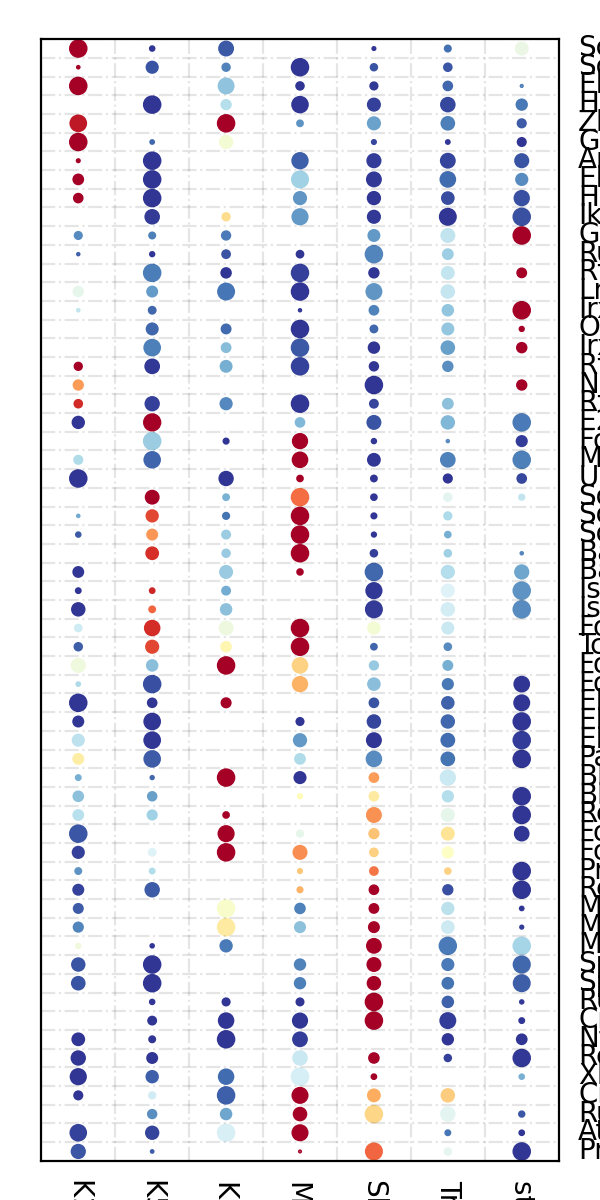

In [285]:

plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=dotplot_concat_filter,
    x='knn_label',          # Column names
    y='eRegulon',
    value='gene_based_AUC',  # For dot size
    c='gene_based_AUC',     # For dot color
    s='region_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap1.pdf",bbox_inches='tight')
plt.show()

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 32.11530606913975
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/1169320158.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


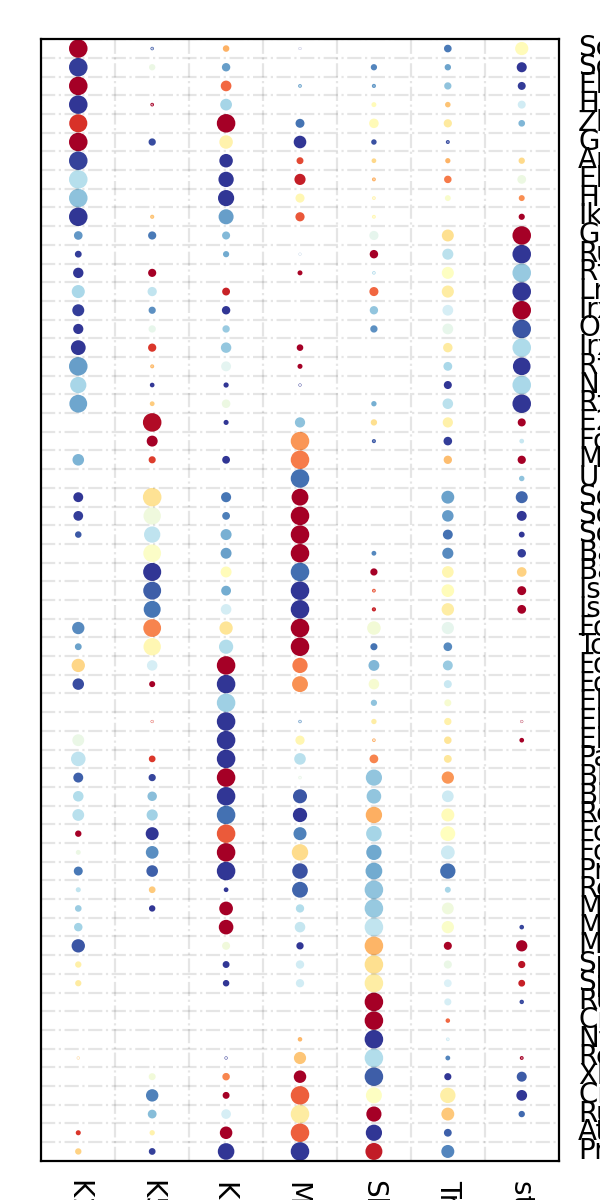

In [325]:

plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=dotplot_concat_filter,
    x='knn_label',          # Column names
    y='eRegulon',
    value='gene_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap2.pdf",bbox_inches='tight')
plt.show()

## Cell Cluster specific

In [305]:
K14_reg = df_activators["K14(-)"].sort_values(ascending=False).head(30).index
cleaned_K14 = [x.split('_(')[0] for x in K14_reg]
dotplot_concat_filter_K14 = dotplot_concat[dotplot_concat.eRegulon.isin(cleaned_K14)]
dotplot_concat_filter_K14['knn_label'] = pd.Categorical(dotplot_concat_filter_K14['knn_label'], 
                                categories=['K14(-)','K6+ cells','Mature K5(-) ','K5(-)','Shh(+)','Transit','stem cells'], 
                                ordered=True)

# Sort the DataFrame
dotplot_concat_filter_K14_sorted = dotplot_concat_filter_K14.sort_values('knn_label')

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 128.461224276559
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/131232848.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


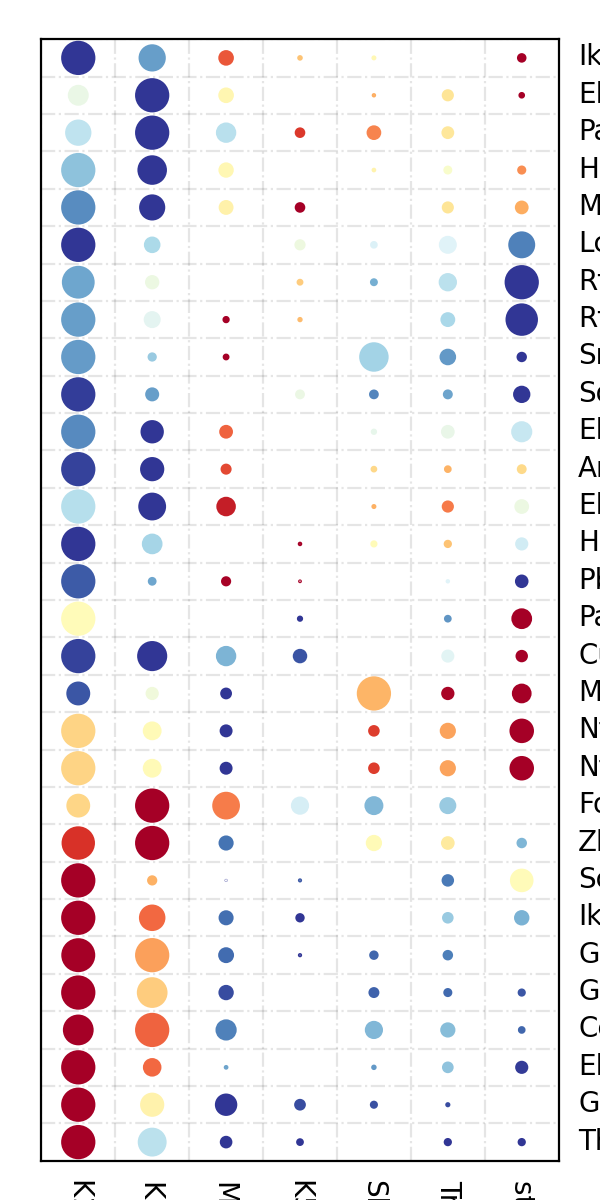

In [306]:
plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=dotplot_concat_filter_K14_sorted,
    x='knn_label',          # Column names
    y='eRegulon',
    value='region_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap_K14.pdf",bbox_inches='tight')
plt.show()

In [ ]:
K14_reg = df_activators["K14(-)"].sort_values(ascending=False).head(30).index
cleaned_K14 = [x.split('_(')[0] for x in K14_reg]
dotplot_concat_filter_K14 = dotplot_concat[dotplot_concat.eRegulon.isin(cleaned_K14)]
dotplot_concat_filter_K14['knn_label'] = pd.Categorical(dotplot_concat_filter_K14['knn_label'], 
                                categories=['K14(-)','K6+ cells','Mature K5(-) ','K5(-)','Shh(+)','Transit','stem cells'], 
                                ordered=True)

# Sort the DataFrame
dotplot_concat_filter_K14_sorted = dotplot_concat_filter_K14.sort_values('knn_label')

In [315]:
def filter_and_sort_regulons(rss, df, cell_type, n_top=30, 
                           cell_order=['K14(-)','K6+ cells','Mature K5(-) ','K5(-)','Shh(+)','Transit','stem cells']):
    """
    Filter and sort regulons based on top expressed genes in a specific cell type
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Original dataframe containing regulon data
    cell_type : str
        Cell type to filter for (e.g., 'K14(-)')
    n_top : int, optional
        Number of top regulons to select (default: 30)
    cell_order : list, optional
        Order of cell types for sorting
        
    Returns:
    --------
    pandas.DataFrame
        Filtered and sorted dataframe
    """
    # Get top regulons for specified cell type
    top_regulons = rss[cell_type].sort_values(ascending=False).head(n_top).index
    
    # Clean regulon names (remove the part after '_(')
    cleaned_regulons = [x.split('_(')[0] for x in top_regulons]
    
    # Filter original dataframe
    filtered_df = df[df.eRegulon.isin(cleaned_regulons)]
    
    # Convert knn_label to categorical with specified order
    filtered_df['knn_label'] = pd.Categorical(
        filtered_df['knn_label'],
        categories=cell_order,
        ordered=True
    )
    
    # Sort the DataFrame
    sorted_df = filtered_df.sort_values('knn_label')
    
    return sorted_df

# Example usage:
# dotplot_concat_filter_K14_sorted = filter_and_sort_regulons(
#     df=df_activators,
#     cell_type='K14(-)',
#     n_top=30
# )

# You can also customize the cell order:
# dotplot_concat_filter_K14_sorted = filter_and_sort_regulons(
#     df=df_activators,
#     cell_type='K14(-)',
#     n_top=30,
#     cell_order=['K14(-)', 'K5', 'stem cells']
# )

In [314]:
df_activators["K6+ cells"].sort_values(ascending=False)

Elf3_extended_+/-_(19g)      0.435097
Elk3_extended_+/-_(46g)      0.382936
Foxq1_extended_+/-_(26g)     0.309655
Zbtb7b_extended_+/+_(28g)    0.301524
Foxq1_extended_+/+_(208g)    0.301032
                               ...   
Hivep1_extended_+/-_(21g)         NaN
Nkx2-4_extended_+/+_(11g)         NaN
Pknox1_extended_+/+_(11g)         NaN
Shox2_extended_+/+_(21g)          NaN
Zfp770_extended_+/-_(11g)         NaN
Name: K6+ cells, Length: 389, dtype: float64

In [316]:
K6Mat = filter_and_sort_regulons(rss=df_activators,df = dotplot_concat,cell_type= "K6+ cells")

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 128.461224276559
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/1176690639.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


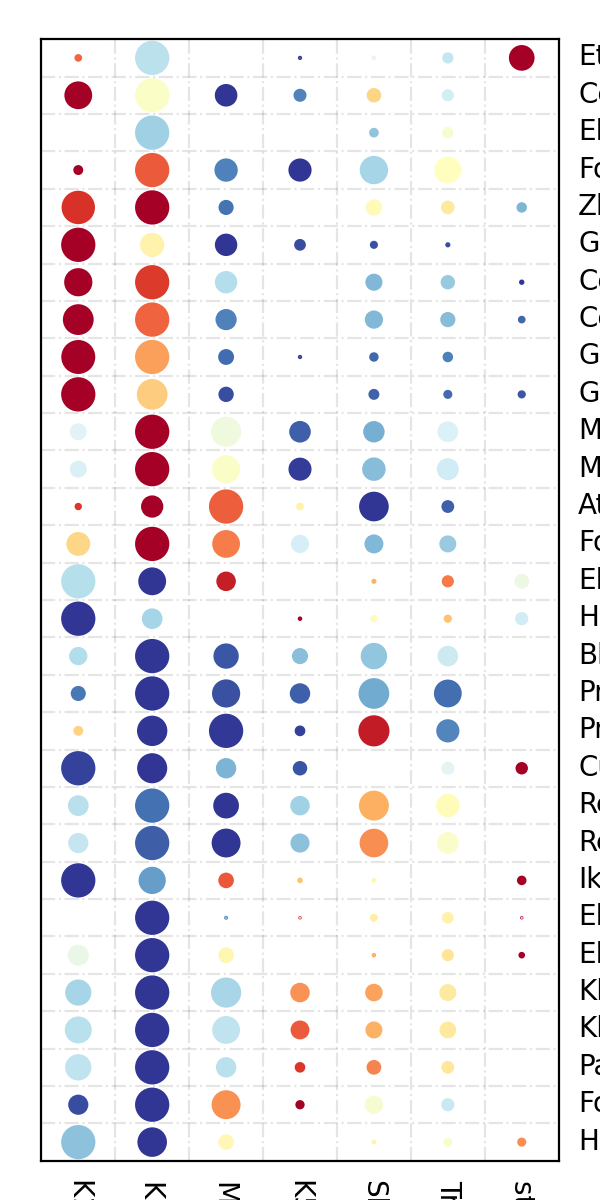

In [317]:
plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=K6Mat,
    x='knn_label',          # Column names
    y='eRegulon',
    value='region_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap_K6.pdf",bbox_inches='tight')
plt.show()

In [318]:
K5Mat = filter_and_sort_regulons(rss=df_activators,df = dotplot_concat,cell_type= "K5(-)")

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 128.461224276559
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/2996970439.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


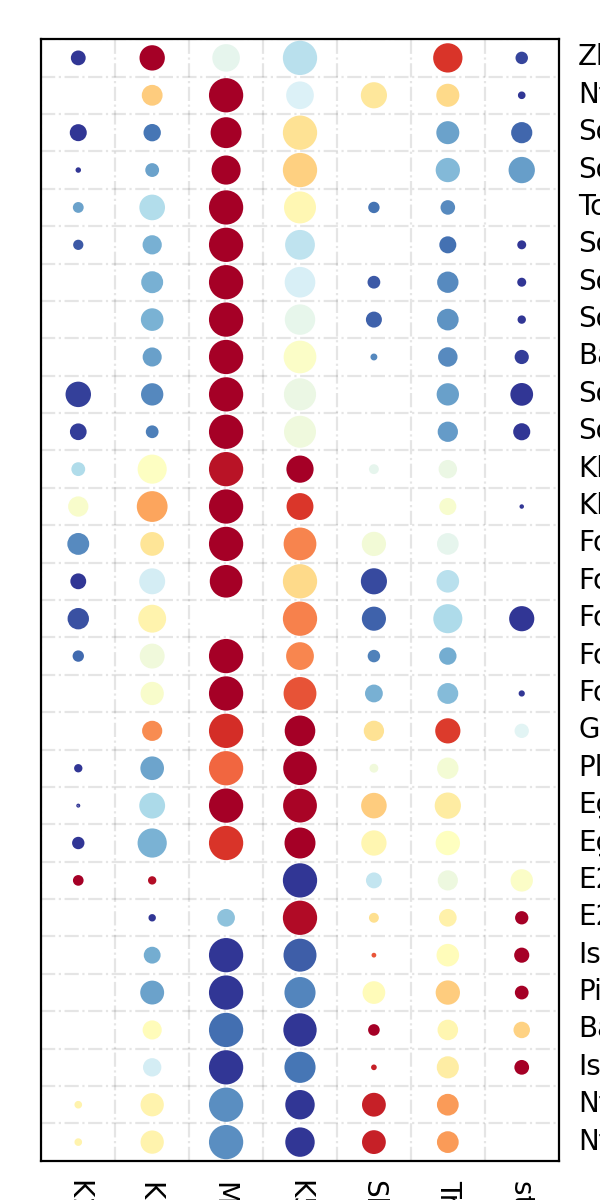

In [319]:
plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=K5Mat,
    x='knn_label',          # Column names
    y='eRegulon',
    value='region_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap_K5.pdf",bbox_inches='tight')
plt.show()

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 137.47336724007502
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/1677700122.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


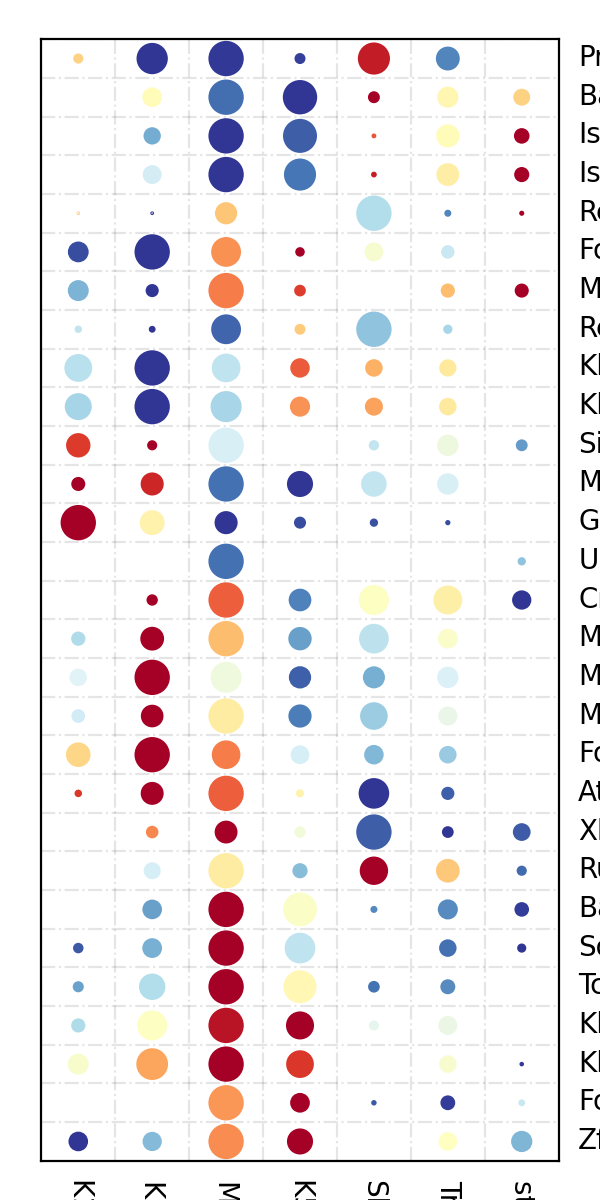

In [321]:
MatureK5Mat = filter_and_sort_regulons(rss=df_activators,df = dotplot_concat,cell_type= "Mature K5(-) ")
plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=MatureK5Mat,
    x='knn_label',          # Column names
    y='eRegulon',
    value='region_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap_Mature_K5.pdf",bbox_inches='tight')
plt.show()

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 137.47336724007502
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/2942668572.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


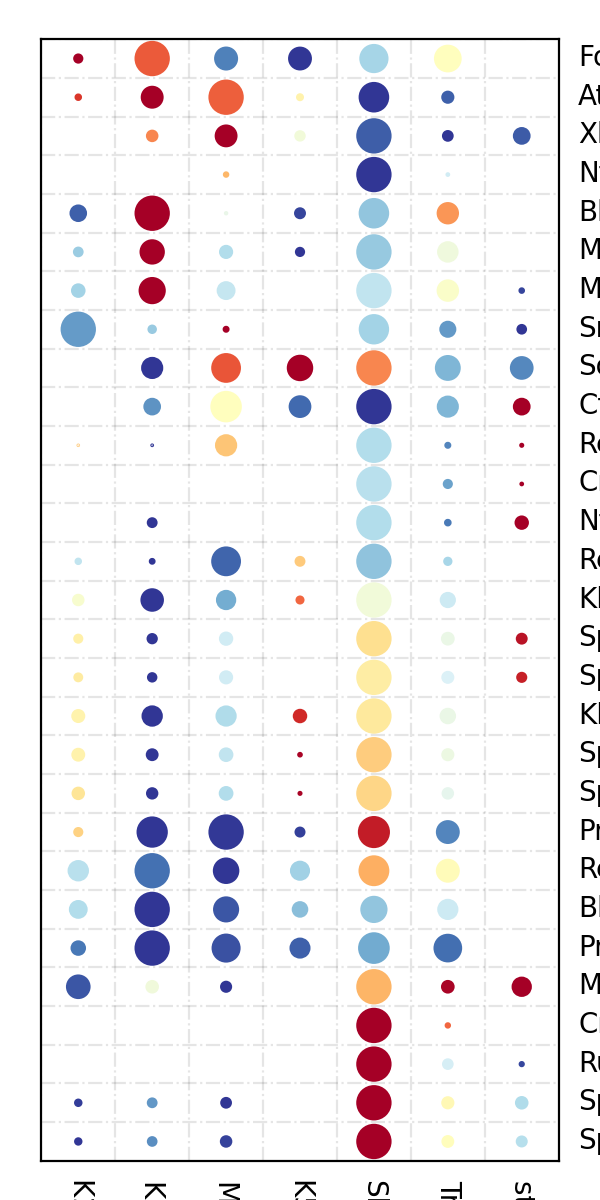

In [322]:
ShhMat = filter_and_sort_regulons(rss=df_activators,df = dotplot_concat,cell_type= "Shh(+)")
plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=ShhMat,
    x='knn_label',          # Column names
    y='eRegulon',
    value='region_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap_Mature_Shh.pdf",bbox_inches='tight')
plt.show()

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 128.461224276559
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/3726981442.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


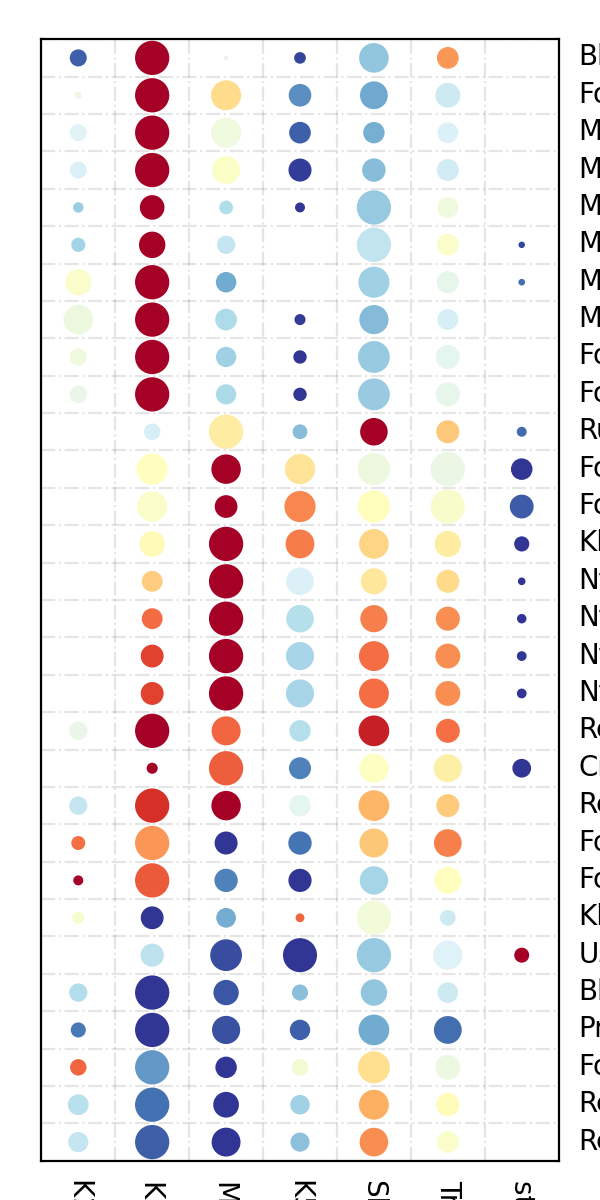

In [323]:
TransitMat = filter_and_sort_regulons(rss=df_activators,df = dotplot_concat,cell_type= "Transit")
plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=TransitMat,
    x='knn_label',          # Column names
    y='eRegulon',
    value='region_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap_TransitMat.pdf",bbox_inches='tight')
plt.show()

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 128.461224276559
Plotting legends..
Estimated legend width: 35.102777777777774 mm


/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/PyComplexHeatmap/utils.py:632: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/tmp/ipykernel_3300996/2632314750.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


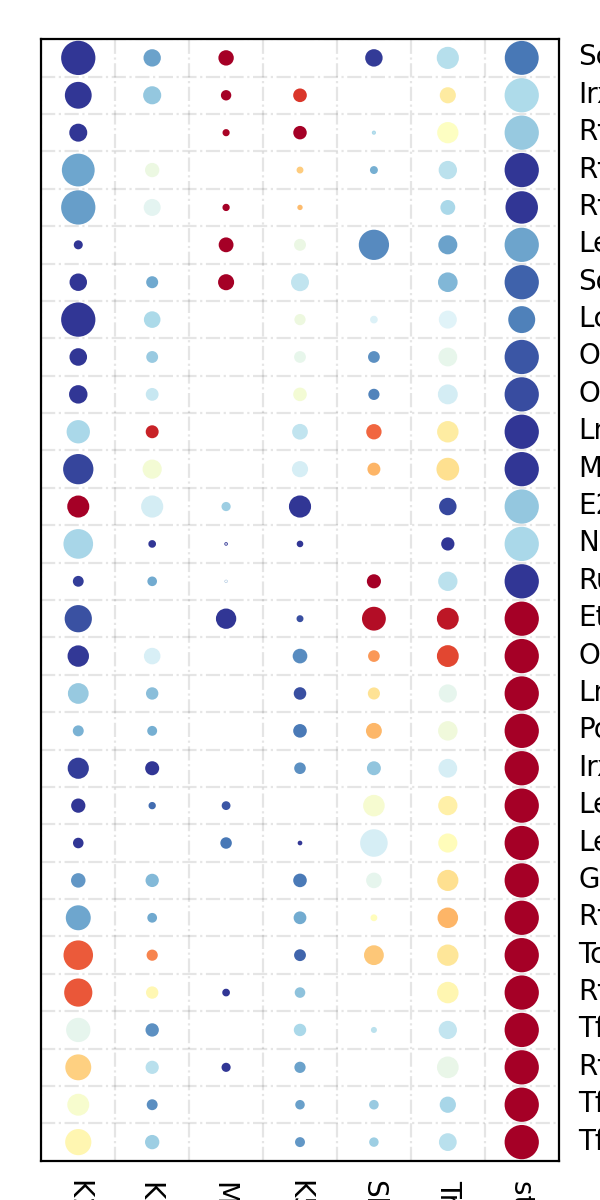

In [324]:
StemMat = filter_and_sort_regulons(rss=df_activators,df = dotplot_concat,cell_type= "stem cells")
plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=StemMat,
    x='knn_label',          # Column names
    y='eRegulon',
    value='region_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap_stemcell.pdf",bbox_inches='tight')
plt.show()

In [326]:
dotplot_concat_filter

,knn_label,region_based_AUC,eRegulon,gene_based_AUC
typing.Literal[<no_default>],,,,
14,K14(-),0.453230,E2f7_direct_+/+,0.000000
16,K14(-),1.000000,Elf1_direct_+/+,1.000000
19,K14(-),0.435235,Fosb_direct_+/+,0.017593
22,K14(-),0.137353,Foxp2_direct_+/+,0.367966
30,K14(-),0.272066,Maf_direct_+/+,0.059033
...,...,...,...,...
2025,stem cells,0.000000,Rfx3_extended_+/-,0.888944
2026,stem cells,0.263752,Rfx7_extended_+/-,1.000000
2033,stem cells,0.933099,Sp5_extended_+/-,0.065291


In [ ]:

plt.figure(figsize=(3, 6))  # Adjust figure size as needed
plt.subplots_adjust(left=0.3, right=0.9, top=0.9, bottom=0.1)  # Adjust these values
cm = DotClustermapPlotter(
    data=dotplot_concat_filter,
    x='knn_label',          # Column names
    y='eRegulon',
    value='gene_based_AUC',  # For dot size
    c='region_based_AUC',     # For dot color 
    s='gene_based_AUC',   # Size mapping
    cmap='RdYlBu_r',        # Color map for gene_based_AUC
    vmin=0,                 # Minimum value for color scaling
    vmax=1,                 # Maximum value for color scaling
    row_cluster=True,       # Enable row clustering
    col_cluster=False,      # Disable column clustering
    show_rownames=True,     # Show eRegulon names
    show_colnames=True,     # Show cell type names
    spines=True,           # Show border lines
    legend_gap=7           # Adjust legend spacing
)
plt.tight_layout()

plt.savefig("../result/regulation/20241221_scenicplus/20241225_dotHeatmap2.pdf",bbox_inches='tight')
plt.show()

In [92]:
from scenicplus.scenicplus_class import mudata_to_scenicplus
scplus_obj = mudata_to_scenicplus(
    mdata = scplus_mdata,
    path_to_cistarget_h5 = "../process/20241219_scenicplus_outs/ctx_results.hdf5",
    path_to_dem_h5 = "../process/20241219_scenicplus_outs/dem_results.hdf5"
)

In [116]:
from scenicplus.grn_builder.gsea_approach import build_grn

In [117]:
build_grn

<function scenicplus.grn_builder.gsea_approach.build_grn(tf_to_gene: pandas.core.frame.DataFrame, region_to_gene: pandas.core.frame.DataFrame, cistromes: anndata._core.anndata.AnnData, is_extended: bool, temp_dir: str, order_regions_to_genes_by='importance', order_TFs_to_genes_by='importance', gsea_n_perm=1000, quantiles=(0.85, 0.9), top_n_regionTogenes_per_gene=(5, 10, 15), top_n_regionTogenes_per_region=(), binarize_using_basc=False, min_regions_per_gene=0, rho_dichotomize_tf2g=True, rho_dichotomize_r2g=True, rho_dichotomize_eregulon=True, keep_only_activating=False, rho_threshold=0.03, NES_thr=0, adj_pval_thr=1, min_target_genes=5, n_cpu=1, merge_eRegulons=True, disable_tqdm=False, **kwargs) -> List[scenicplus.grn_builder.modules.eRegulon]>

In [100]:
scplus_mdata

MuData object with n_obs × n_vars = 3756 × 520660
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	3756 x 23143
      obs:	'knn_label'
    scATAC_counts:	3756 x 496513
      obs:	'knn_label'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	3756 x 193
    direct_region_based_AUC:	3756 x 193
    extended_gene_based_AUC:	3756 x 309
    extended_region_based_AUC:	3756 x 309

In [105]:
scplus_obj.uns.keys()

dict_keys(['eRegulon_metadata', 'eRegulon_AUC'])

In [109]:
scplus_obj.uns['eRegulon_metadata']

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr3:59248033-59248533,P2ry12,0.024134,0.081957,0.001978,0.001978,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(29g),Atf2_direct_+/+_(28r),0.680403,1,0.099793,30468
1,chr10:93282649-93283149,Snrpf,0.050576,0.345080,0.017453,0.017453,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(29g),Atf2_direct_+/+_(28r),0.562857,1,0.439785,12520
2,chr17:75048161-75048661,Birc6,0.030685,0.185504,0.005692,0.005692,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(29g),Atf2_direct_+/+_(28r),0.364849,1,0.462404,33365
3,chr19:4859068-4859568,Rbm4b,0.043839,0.201638,0.008840,0.008840,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(29g),Atf2_direct_+/+_(28r),0.499448,1,0.332775,30687
4,chr12:81175347-81175847,Smoc1,0.022144,0.103545,0.002293,0.002293,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(29g),Atf2_direct_+/+_(28r),1.072132,1,0.068621,23737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169512,chr3:121953903-121954403,Arhgap29,0.001251,-0.291169,-0.000364,0.000364,Trp73,True,Trp73_extended_-/-,Trp73_extended_-/-_(27g),Trp73_extended_-/-_(41r),0.211194,-1,-0.304172,106659
169513,chr14:98170873-98171373,Dach1,0.066717,-0.321349,-0.021439,0.021439,Trp73,True,Trp73_extended_-/-,Trp73_extended_-/-_(27g),Trp73_extended_-/-_(41r),0.167312,-1,-0.213841,37206
169514,chr18:23667059-23667559,Dtna,0.003549,-0.175477,-0.000623,0.000623,Trp73,True,Trp73_extended_-/-,Trp73_extended_-/-_(27g),Trp73_extended_-/-_(41r),0.140136,-1,-0.163815,100650
169515,chr7:97701037-97701537,Capn5,0.083379,-0.244558,-0.020391,0.020391,Trp73,True,Trp73_extended_-/-,Trp73_extended_-/-_(27g),Trp73_extended_-/-_(41r),0.159304,-1,-0.112302,20527


In [111]:
scplus_obj

SCENIC+ object with n_cells x n_genes = 3756 x 23143 and n_cells x n_regions = 3756 x 496513
	metadata_regions:'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
	metadata_cell:'knn_label'
	menr:'cistar_DARs_cell_type_K14(-)', 'cistar_DARs_cell_type_K5(-)', 'cistar_DARs_cell_type_K6+ cells', 'cistar_DARs_cell_type_Mature K5(-) ', 'cistar_DARs_cell_type_Shh(+)', 'cistar_DARs_cell_type_Transit', 'cistar_DARs_cell_type_stem cells', 'cistar_Topics_otsu_Topic1', 'cistar_Topics_otsu_Topic10', 'cistar_Topics_otsu_Topic11', 'cistar_Topics_otsu_Topic12', 'cistar_Topics_otsu_Topic13', 'cistar_Topics_otsu_Topic14', 'cistar_Topics_otsu_Topic15', 'cistar_Topics_otsu_Topic16', 'cistar_Topics_otsu_Topic17', 'cistar_Topics_otsu_Topic18', 'cistar_Topics_otsu_Topic19', 'cistar_Topics_otsu_Topic2', 'cistar_Topics_otsu_Topic20', 'cistar_Topics_otsu_Topic3', 'cistar_Topics_otsu_Topic4', 'cistar_Topics_otsu_Topic5', 'cistar_Topics_otsu

In [113]:
scenicplus.__version__

'1.0a1'

In [ ]:
import scenicplus

In [115]:
scenicplus.networks

AttributeError: module 'scenicplus' has no attribute 'networks'

In [108]:
net = scenicplus.utils.eRegulons_to_networkx(scplus_obj,eRegulons_key_to_use = "eRegulon_metadata",only_keep_extended_if_not_direct = False)

AttributeError: 'str' object has no attribute 'context'

In [107]:
net = scenicplus.utils.eRegulons_to_networkx(scplus_mdata,eRegulons_key_to_use = "extended_e_regulon_metadata")

AttributeError: 'str' object has no attribute 'is_extended'